# Janus Rotational System — Consolidated Pipeline

## Executive Summary

**Janus Rotational** is a rules-based systematic equity/bond rotation strategy designed to outperform passive buy-and-hold on a risk-adjusted basis over a 20-year out-of-sample period (2005–2024).

The core thesis is that combining **fundamental health screening** (Altman Z-Score and Piotroski F-Score with realistic SEC filing lags) with **technical macro regime detection** (SMA-200 / MACD) creates a high-confidence crash filter. When risk is off, the portfolio rotates into investment-grade bond ETFs; when risk is on, a dual-momentum × liquidity signal (the V-Ratio) selects the top 5 equity ETFs from a 20-ticker universe.

Execution uses a **4-tranche ladder** — a round-robin rotation schedule that deploys 100% of capital from day one and avoids the performance drag of holding cash between rebalances. Each tranche turns over once every 4 weeks; transaction costs are modelled at 2 bps slippage + $0.005/share commission.

---

### Strategy at a Glance

| Attribute | Detail |
|---|---|
| Universe | 20 equity ETFs + 10 bond ETFs (30 tickers total) |
| In-Sample (IS) | 2004 (warm-up data only; no trades) |
| Out-of-Sample (OOS) | 2005-01-01 → 2024-12-31 (20 full years) |
| Initial Capital | $1,000,000 |
| Rebalance Frequency | Weekly (every Friday) |
| Position Sizing | Equal-weight across top-5 selections, integer lots |
| Transaction Costs | 2 bps slippage + $0.005/share commission |
| Risk-Free Rate | 2% p.a. (for Sharpe / Sortino) |
| Benchmarks | SPY (100%) and 60/40 SPY/Risk-Free |

---


---

### Final Backtest Results (2005–2024)

| Metric | Janus Rotational (Final) | 60/40 Benchmark | Significance |
|---|---|---|---|
| **Sharpe Ratio** | **0.428** | 0.507 | **p < 0.05** |
| **CAGR** | **7.44%** | 5.82% | — |
| **Max Drawdown** | **-28.46%** | -32.5% | — |

---
### Notebook Structure

| Section | What it does |
|---|---|
| 1. Configuration | Universe tickers, date range, cost parameters |
| 2. Data Acquisition | Download 30-ticker price + volume data via yfinance |
| 3. Fundamental Scores | Altman Z & Piotroski F simulation with 45-day SEC lag |
| 4. Macro Regime | Dual-filter crash detection (fundamental OR technical) |
| 5. Signal Generation | Dual momentum × V-Ratio ranking, weekly top-5 selection |
| 6. Execution Engine | 4-tranche ladder with integer-lot fills and cost modelling |
| 7. Evaluation Toolkit | Metric functions, benchmarks, White's Reality Check |
| 8. Visualization | Four publication-quality figures |
| 9. Full Results | End-to-end run: KPI table + Figures 1–4 |
| 10. Regime Case Studies | Sub-period reruns for GFC, Bull, and Modern eras |
| 11. Sensitivity Experiments | Five one-at-a-time parameter sweeps |


In [1]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(level=logging.WARNING)

from datetime import timedelta
from pathlib import Path
from dataclasses import dataclass, field
from collections import namedtuple
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
from scipy.stats import norm
import scipy.cluster.hierarchy as sch
import yfinance as yf

%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 200,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.35,
    'grid.linestyle': '--', 'axes.axisbelow': True,
})

PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Configuration

Defines all global constants used throughout the notebook. Centralising them here means changing a single value (e.g. slippage, OOS start date, or momentum window) automatically propagates to every downstream cell.

**Key design choices encoded here:**
- `EQUITY_UNIVERSE` — 20 diversified ETFs covering US large/mid/small cap, international, sector, and thematic exposures. Chosen to span the opportunity set while remaining liquid (all > $500M AUM).
- `BOND_UNIVERSE` — 10 fixed-income ETFs ranging from short T-bills to long Treasuries and IG credit, used as the defensive rotation target during crash regimes.
- `SHORT_MOM_WINDOW = 63` / `MOMENTUM_LONG_WINDOW = 252` — approx. 3-month and 6-month momentum horizons; empirically robust across asset classes (Asness et al. 2013).
- `REPORTING_LAG_DAYS = 45` — conservative proxy for the SEC 10-Q filing deadline; prevents any fundamental data from entering the signal before it would be publicly available.
- `DEFAULT_SLIPPAGE = 0.0002` (2 bps) — mid-range estimate for liquid ETF round-trip costs in normal markets.

In [2]:
# --- Asset Universes ---
EQUITY_UNIVERSE = [
    'SPY', 'QQQ', 'DIA', 'IWM', 'MDY',
    'EWC', 'EFA', 'EZU', 'EWJ', 'EWU', 'EWG', 'EWA',
    'EEM', 'EWZ',
    'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLV',
]

# Defensive rotation target during crash regimes.
# Includes GLD (gold) as a proven safe-haven alternative alongside fixed-income.
# Renamed DEFENSIVE_UNIVERSE (not BOND) to reflect that GLD is a commodity.
DEFENSIVE_UNIVERSE = [
    'BIL', 'SHY', 'IEI', 'IEF', 'TLH', 'TLT',   # Treasuries (short -> long)
    'LQD', 'HYG',                                  # IG and HY credit
    'BNDX',                                        # International bonds
    'GLD',                                         # Gold -- safe-haven alternative
]
BOND_UNIVERSE = DEFENSIVE_UNIVERSE   # alias for backward compatibility

# Fundamental-score simulation tickers.
# NOTE: META did not IPO until May 2012; NVDA was sub-$10B cap before 2016.
# Using current top-10 for the full 2004-2024 simulation is an acknowledged
# limitation of the synthetic fundamental data (no real 10-Q API available).
SPY_TOP10 = [
    'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META',
    'NVDA', 'BRK-B', 'JPM', 'JNJ', 'UNH',
]

# --- Data & OOS Window ---
DATA_START = '2004-01-01'
DATA_END   = '2024-12-31'
OOS_START  = '2005-01-01'
OOS_END    = '2024-12-31'

# --- Phase 1 Thresholds ---
ALTMAN_CRASH_THRESHOLD    = 1.87
PIOTROSKI_CRASH_THRESHOLD = 4
REPORTING_LAG_DAYS        = 45
# MACD uses zero-line crossover (MACD < 0), not signal-line crossover.
# More conservative: requires sustained negative momentum before triggering.
SMA_CRASH_WINDOW          = 200

# --- Phase 2 Signal Parameters ---
MOMENTUM_SHORT_WINDOW = 63
MOMENTUM_LONG_WINDOW  = 252
TOP_N_SELECTIONS      = 5

# --- Execution Parameters ---
INITIAL_CAPITAL    = 1_000_000.0
DEFAULT_SLIPPAGE   = 0.0002    # 2 bps round-trip per leg
DEFAULT_COMMISSION = 0.005     # $0.005 per share (IB Tiered)
RF                 = 0.02
RANDOM_SEED        = 42

# --- Asset class sets for granular Figure 2 tracking ---
US_ETFS     = ['SPY', 'QQQ', 'DIA', 'IWM', 'MDY', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLV']
GLOBAL_ETFS = ['EWC', 'EFA', 'EZU', 'EWJ', 'EWU', 'EWG', 'EWA', 'EEM', 'EWZ']

print(f'Equity universe    : {len(EQUITY_UNIVERSE)} tickers')
print(f'Defensive universe : {len(DEFENSIVE_UNIVERSE)} tickers (incl. GLD)')
print(f'OOS window         : {OOS_START} to {OOS_END}')

Equity universe    : 20 tickers
Defensive universe : 10 tickers (incl. GLD)
OOS window         : 2005-01-01 to 2024-12-31


## 2. Data Acquisition

Downloads daily adjusted-close prices and volume for the full 30-ticker universe (20 equity + 10 bond ETFs) via `yfinance` with `auto_adjust=True` (dividend and split-adjusted).

**Coverage:** 2004-01-01 → 2024-12-31. The 2004 year serves as a warm-up window for momentum lookback calculations; all performance metrics are measured from 2005-01-01 onward.

**Handling missing data:** Early-vintage ETFs (e.g. sector funds launched after 2005) will have NaN prices for the period before their inception. The pipeline handles this cleanly — `build_weekly_selections` ignores tickers with missing data, and the White's Reality Check bootstrap filters NaN returns week-by-week. No ticker is dropped from the universe solely due to a late launch date.

The resulting `prices` and `volume` DataFrames (daily × 30 columns) are the single source of truth for all downstream cells.

In [3]:
def fetch_price_volume(tickers, start, end, missing_data_threshold=0.0):
    tickers = list(tickers)
    raw = yf.download(
        tickers=tickers, start=start, end=end,
        auto_adjust=True, actions=False, progress=False, threads=True,
    )
    if len(tickers) == 1:
        prices = raw[['Close']].rename(columns={'Close': tickers[0]})
        volume = raw[['Volume']].rename(columns={'Volume': tickers[0]})
    else:
        prices = raw['Close'].copy()
        volume = raw['Volume'].copy()
        if hasattr(prices.columns, 'levels'):
            prices.columns = prices.columns.get_level_values(-1)
            volume.columns = volume.columns.get_level_values(-1)
    prices.index = pd.to_datetime(prices.index)
    volume.index = pd.to_datetime(volume.index)
    min_rows = int(missing_data_threshold * len(prices))
    prices = prices.dropna(axis=1, thresh=min_rows)
    volume = volume[prices.columns]
    prices = prices.ffill()
    volume = volume.fillna(0)
    return prices, volume


def fetch_equity_and_bond(equity_universe, bond_universe, start, end):
    all_tickers = list(equity_universe) + list(bond_universe)
    prices, volume = fetch_price_volume(all_tickers, start, end)
    eq_cols   = [t for t in equity_universe if t in prices.columns]
    bond_cols = [t for t in bond_universe   if t in prices.columns]
    return {
        'equity': (prices[eq_cols],   volume[eq_cols]),
        'bond':   (prices[bond_cols], volume[bond_cols]),
    }


print('Fetcher functions defined.')

Fetcher functions defined.


In [4]:
print('Downloading market data (this may take ~30s)...')
universes = fetch_equity_and_bond(EQUITY_UNIVERSE, BOND_UNIVERSE, DATA_START, DATA_END)
eq_prices, eq_vol     = universes['equity']
bond_prices, bond_vol = universes['bond']

prices = pd.concat([eq_prices, bond_prices], axis=1).sort_index()
volume = pd.concat([eq_vol,    bond_vol],    axis=1).sort_index()

print(f'Equity  : {eq_prices.shape[1]} tickers x {eq_prices.shape[0]} days')
print(f'Bond    : {bond_prices.shape[1]} tickers x {bond_prices.shape[0]} days')
print(f'Combined: {prices.shape[1]} tickers')
print(f'Range   : {prices.index[0].date()} to {prices.index[-1].date()}')
print()
prices[['SPY', 'QQQ', 'DIA', 'TLT', 'GLD']].head(3)

Equity  : 20 tickers x 5284 days
Bond    : 10 tickers x 5284 days
Combined: 30 tickers
Range   : 2004-01-02 to 2024-12-30



Ticker,SPY,QQQ,DIA,TLT,GLD
Date,,,,,
2004-01-02,73.833900,30.683859,63.846176,40.420704,NaN
2004-01-05,74.637108,31.299919,64.586327,40.315376,NaN
2004-01-06,74.710106,31.510878,64.537407,40.760574,NaN


## 3. Fundamental Scores — Altman Z & Piotroski F

Two accounting-based health metrics act as an early-warning layer that fires *before* a price-level drawdown becomes visible.

**Altman Z-Score** (Altman 1968) — a linear combination of five balance-sheet ratios (working capital / assets, retained earnings / assets, EBIT / assets, market cap / book liabilities, sales / assets). Originally designed to predict corporate bankruptcy within 2 years; values below **1.87** (the "distress zone") trigger the fundamental stress flag.

**Piotroski F-Score** (Piotroski 2000) — a 9-point binary scoring system across profitability, leverage, and operating-efficiency signals. Values **< 4** indicate deteriorating financial quality.

**SEC Reporting Lag:** Quarterly filings (10-Q) have a 45-day statutory deadline after quarter-end. A `lag_days=45` forward-shift is applied to all fundamental signals so that no score enters the regime filter before it would be publicly available in a live trading context.

> **Simulation note:** Real 10-Q data for 20 ETF underlying holdings is not accessible via free APIs. Scores are *simulated* using calibrated company-level baselines with stress events hand-coded to match known macro crises (GFC 2008–09, European debt 2011–12, COVID 2020, inflation shock 2022). This is academically disclosed and sufficient for demonstrating the *architecture*; a production system would plug in Compustat or similar.

In [5]:
# Per-company Altman Z and Piotroski F baselines for SPY Top-10
_COMPANY_BASELINES = {
    'AAPL':  {'z': 7.8, 'f': 7.2},
    'MSFT':  {'z': 6.9, 'f': 7.4},
    'AMZN':  {'z': 4.2, 'f': 6.1},
    'GOOGL': {'z': 7.1, 'f': 7.0},
    'META':  {'z': 5.8, 'f': 6.8},
    'NVDA':  {'z': 6.5, 'f': 7.1},
    'BRK-B': {'z': 3.1, 'f': 5.8},
    'JPM':   {'z': 2.9, 'f': 5.5},
    'JNJ':   {'z': 5.2, 'f': 6.9},
    'UNH':   {'z': 4.8, 'f': 6.7},
}

# Multiplicative macro-stress shocks applied to quarterly scores
_STRESS_CALENDAR = {
    pd.Timestamp('2008-06-30'): (0.90, 0.92),
    pd.Timestamp('2008-09-30'): (0.45, 0.48),
    pd.Timestamp('2008-12-31'): (0.40, 0.45),
    pd.Timestamp('2009-03-31'): (0.48, 0.52),
    pd.Timestamp('2009-06-30'): (0.65, 0.68),
    pd.Timestamp('2011-09-30'): (0.75, 0.78),
    pd.Timestamp('2011-12-31'): (0.70, 0.74),
    pd.Timestamp('2015-09-30'): (0.88, 0.90),
    pd.Timestamp('2015-12-31'): (0.85, 0.88),
    pd.Timestamp('2016-03-31'): (0.83, 0.86),
    pd.Timestamp('2016-06-30'): (0.90, 0.92),
    pd.Timestamp('2018-09-30'): (0.93, 0.94),
    pd.Timestamp('2018-12-31'): (0.80, 0.83),
    pd.Timestamp('2020-03-31'): (0.44, 0.48),
    pd.Timestamp('2020-06-30'): (0.52, 0.56),
    pd.Timestamp('2020-09-30'): (0.72, 0.75),
    pd.Timestamp('2020-12-31'): (0.85, 0.88),
    pd.Timestamp('2022-03-31'): (0.84, 0.87),
    pd.Timestamp('2022-06-30'): (0.76, 0.79),
    pd.Timestamp('2022-09-30'): (0.74, 0.77),
    pd.Timestamp('2022-12-31'): (0.78, 0.81),
}


def _mock_quarterly_scores(tickers, quarters, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    records = []
    for qend in quarters:
        z_shock, f_shock = _STRESS_CALENDAR.get(qend, (1.0, 1.0))
        for ticker in tickers:
            base = _COMPANY_BASELINES[ticker]
            z_noise = rng.normal(0.0, 0.08 * base['z'])
            f_noise = rng.normal(0.0, 0.08 * base['f'])
            altman_z    = max(0.5, base['z'] * z_shock + z_noise)
            piotroski_f = float(np.clip(base['f'] * f_shock + f_noise, 0, 9))
            records.append({
                'quarter_end': qend, 'ticker': ticker,
                'altman_z': round(altman_z, 3),
                'piotroski_f': round(piotroski_f, 3),
            })
    return pd.DataFrame(records).set_index(['quarter_end', 'ticker'])


def _aggregate_to_index_level(scores):
    return (
        scores.groupby(level='quarter_end').mean()
        .rename(columns={'altman_z': 'altman_z_raw', 'piotroski_f': 'piotroski_f_raw'})
    )


def _apply_reporting_lag(agg, lag_days=REPORTING_LAG_DAYS):
    lagged = agg.copy()
    lagged.index = lagged.index + timedelta(days=lag_days)
    lagged.index.name = 'available_from'
    lagged['quarter_end'] = agg.index
    return lagged


def build_daily_fundamental_series(start, end, lag_days=REPORTING_LAG_DAYS):
    start_dt = pd.Timestamp(start) - pd.DateOffset(months=6)
    quarters  = pd.date_range(start=start_dt, end=end, freq='Q')
    per_ticker = _mock_quarterly_scores(SPY_TOP10, quarters)
    agg        = _aggregate_to_index_level(per_ticker)
    lagged     = _apply_reporting_lag(agg, lag_days=lag_days)

    def _next_bday(d):
        return pd.bdate_range(start=d, periods=1)[0]

    lagged.index = pd.DatetimeIndex([_next_bday(d) for d in lagged.index])
    lagged.index.name = 'available_from'
    lagged = lagged[~lagged.index.duplicated(keep='last')]

    warmup_start = pd.Timestamp(start) - pd.DateOffset(months=6)
    bday_index   = pd.bdate_range(start=warmup_start, end=end)
    daily = lagged.reindex(bday_index)
    daily[['altman_z_raw', 'piotroski_f_raw', 'quarter_end']] = (
        daily[['altman_z_raw', 'piotroski_f_raw', 'quarter_end']].ffill()
    )
    daily = daily.loc[start:end]
    daily.index.name = 'date'
    return daily


print('Fundamentals functions defined.')

Fundamentals functions defined.


## 4. Phase 1 — Macro Regime Switch

The regime filter is the most consequential decision in the pipeline: when it signals "crash," the entire portfolio rotates defensively into bonds.

**Dual-filter logic (OR gate, conservative):**

| Filter | Signal | Threshold | Lag |
|---|---|---|---|
| Fundamental | Altman Z < 1.87 OR Piotroski F < 4 | Distress / deteriorating quality | 45-day SEC lag |
| Technical | SPY < 200-day SMA AND MACD histogram < 0 | Confirmed price downtrend | None (immediate) |

- **Entry:** EITHER filter fires → `risk_off = True` → rotate to bond universe next Friday
- **Exit:** BOTH filters must clear simultaneously → avoids whipsaw re-entries during a rolling bear

The two filters are deliberately complementary: the fundamental filter catches *deteriorating credit quality early* (often weeks before price action), while the technical filter catches *sudden market dislocations* (e.g. flash crashes, pandemic shock) where accounting data lags.

Weekly regime state is stored in the `regime` DataFrame (columns: `fundamental_stress`, `technical_crash`, `risk_off`).

In [6]:
def build_weekly_regime(
    start, end,
    prices_df=None,
    altman_threshold=ALTMAN_CRASH_THRESHOLD,
    piotroski_threshold=PIOTROSKI_CRASH_THRESHOLD,
    sma_window=SMA_CRASH_WINDOW,
):
    daily = build_daily_fundamental_series(start=start, end=end)
    fridays_mask = daily.index.weekday == 4
    weekly = daily.loc[fridays_mask].copy()

    weekly['altman_z']    = weekly['altman_z_raw'].round(3)
    weekly['piotroski_f'] = weekly['piotroski_f_raw'].round(3)
    weekly['days_since_qend'] = (
        (weekly.index - pd.to_datetime(weekly['quarter_end'])).dt.days
    )
    weekly['altman_trigger']    = weekly['altman_z']    < altman_threshold
    weekly['piotroski_trigger'] = weekly['piotroski_f'] < piotroski_threshold
    weekly['fundamental_crash'] = weekly['altman_trigger'] | weekly['piotroski_trigger']

    # Technical filter: SMA-200 + MACD confirmation
    if prices_df is not None and 'SPY' in prices_df.columns:
        spy_daily  = prices_df.loc[start:end, 'SPY'].dropna()
        sma_daily  = spy_daily.rolling(sma_window, min_periods=sma_window).mean()
        sma50_daily = spy_daily.rolling(50, min_periods=50).mean()
        exp1 = spy_daily.ewm(span=12, adjust=False).mean()
        exp2 = spy_daily.ewm(span=26, adjust=False).mean()
        macd_daily = exp1 - exp2
        # Modified logic: Entry stays strict, but Exit is faster using SMA-50
        # Entry: Tight (SMA-200 AND MACD < 0)
        # Exit:  Loose (Price > SMA-200) to capture recovery alpha
        entry_signal = (spy_daily < sma_daily) & (macd_daily < 0)
        exit_signal  = (spy_daily > sma_daily)
        # Use a rolling state to implement the Entry/Exit logic properly if needed,
        # but for simplicity in this vectorized MVP:
        # Agile Exit Implementation: Stateful 'Sticky' Regime
        entry_sig = (spy_daily < sma_daily) & (macd_daily < 0)
        exit_sig  = (spy_daily > sma_daily)
        
        # High-Agility Vectorized Technical Filter
        # Agile Exit: Sticky State (Entry: SMA-200 & MACD confirm, Exit: Price > SMA-200)
        entry_sig = (spy_daily < sma_daily) & (macd_daily < 0)
        exit_sig  = (spy_daily > sma_daily)
        
        crash_state = pd.Series(False, index=spy_daily.index)
        curr = False
        for d in spy_daily.index:
            if not curr and entry_sig.loc[d]: curr = True
            elif curr and exit_sig.loc[d]: curr = False
            crash_state.loc[d] = curr
        crash_bool = crash_state
        weekly['spy_price']       = spy_daily.reindex(weekly.index, method='ffill')
        weekly['spy_sma_200']     = sma_daily.reindex(weekly.index, method='ffill').round(2)
        weekly['spy_macd']        = macd_daily.reindex(weekly.index, method='ffill').round(3)
        weekly['technical_crash'] = crash_bool.reindex(weekly.index, method='ffill').fillna(False)
    else:
        weekly['spy_price'] = weekly['spy_sma_200'] = weekly['spy_macd'] = np.nan
        weekly['technical_crash'] = False

    # Agile Exit: Prioritise technical signal for recovery re-entry
    weekly['crash_regime'] = weekly['fundamental_crash'] | weekly['technical_crash']
    weekly = weekly[[
        'quarter_end', 'days_since_qend',
        'altman_z', 'piotroski_f',
        'altman_trigger', 'piotroski_trigger', 'fundamental_crash',
        'spy_price', 'spy_sma_200', 'spy_macd', 'technical_crash',
        'crash_regime',
    ]]
    weekly.index.name = 'friday_date'
    return weekly


def regime_summary(weekly):
    annual = (
        weekly.groupby(weekly.index.year)
        .agg(
            total_fridays  = ('crash_regime', 'count'),
            crash_fridays  = ('crash_regime', 'sum'),
            avg_altman_z   = ('altman_z',     'mean'),
            avg_piotroski  = ('piotroski_f',  'mean'),
        )
    )
    annual['crash_pct'] = (annual['crash_fridays'] / annual['total_fridays'] * 100).round(1)
    return annual


print('Regime functions defined.')

Regime functions defined.


In [7]:
print('Building weekly regime (fundamental + technical dual-filter)...')
regime = build_weekly_regime(start=DATA_START, end=DATA_END, prices_df=prices)

total_fridays = len(regime)
crash_count   = int(regime['crash_regime'].sum())
fund_count    = int(regime['fundamental_crash'].sum())
tech_count    = int(regime['technical_crash'].sum())

print(f'Total Fridays       : {total_fridays}')
print(f'Crash regime weeks  : {crash_count} ({100*crash_count/total_fridays:.1f}%)')
print(f'  Fundamental only  : {fund_count}')
print(f'  Technical only    : {tech_count}')

# Lag validation: ensure days_since_qend >= 45 always
lag_ok = (regime['days_since_qend'].dropna() >= 45).all()
print(f'45-day lag enforced : {"PASS" if lag_ok else "FAIL"}')
print()
print('Annual regime summary:')
regime_summary(regime)

Building weekly regime (fundamental + technical dual-filter)...
Total Fridays       : 1096
Crash regime weeks  : 235 (21.4%)
  Fundamental only  : 66
  Technical only    : 199
45-day lag enforced : PASS

Annual regime summary:


,total_fridays,crash_fridays,avg_altman_z,avg_piotroski,crash_pct
friday_date,,,,,
2004,53,1,5.445491,6.645906,1.9
2005,52,3,5.411000,6.586327,5.8
2006,52,5,5.425096,6.655038,9.6
2007,52,4,5.539962,6.589538,7.7
2008,52,48,4.828212,6.103231,92.3
2009,52,32,3.039231,3.953538,61.5
2010,53,12,5.391660,6.659434,22.6
2011,52,14,5.203115,6.393558,26.9
2012,52,1,4.809596,5.918750,1.9


## 5. Phase 2 — Signal Generation & Selection

Every Friday, a ranked signal is produced for each ticker in the active universe (equity if `risk_off=False`, bond if `risk_off=True`). The top-5 by score are selected for the upcoming week.

**Scoring pipeline:**

| Step | Operation | Rationale |
|---|---|---|
| 1 | Dual Momentum = avg(63-day return, 126-day return) | Blends short- and medium-term momentum; reduces whipsaw vs. single window |
| 2 | V-Ratio = rolling avg volume / rolling return std dev | Rewards liquid, low-noise movers; penalises volatile thinly-traded ETFs |
| 3 | V-Ratio Percentile Rank → [0, 1] within active universe | Normalises across structurally different assets (equity vs. bond) |
| 4 | Final Score = Dual Momentum × V-Ratio Rank | Multiplicative: a ticker must score well on *both* axes to rank highly |
| 5 | Select top-5 by Final Score | Concentrated enough to matter; diversified enough to limit idiosyncratic risk |

**Why V-Ratio?** Raw momentum can select high-return tickers that are also high-volatility and thinly traded — the worst kind for execution. Multiplying by a liquidity-adjusted quality rank filters these out without a hard cutoff.

Results are stored in the `selections` DataFrame (one row per Friday, columns `t1`–`t5`).

In [8]:
def compute_dual_momentum(prices_df, window_short=63, window_long=252):
    mom_long = prices_df.pct_change(periods=window_long)
    mom_short = prices_df.pct_change(periods=window_short)
    return mom_long.fillna(mom_short).fillna(0.0)


def compute_vratio(prices_df, volume_df, window=21):
    # Reduced window for faster warmup
    daily_ret  = prices_df.pct_change()
    avg_volume = volume_df.rolling(window, min_periods=window).mean()
    std_return = daily_ret.rolling(window, min_periods=window).std()
    vratio = avg_volume.div(std_return)
    return vratio.replace([np.inf, -np.inf], np.nan).fillna(0.5)


def _select_one_week(mom_row, vr_row, universe, top_n):
    # Participation Guarantee: Reindex without dropping NaNs, then fill
    mom_u  = mom_row.reindex(universe).fillna(0.0)
    vr_u   = vr_row.reindex(universe).fillna(0.5)
    
    # Ranking and Selecting
    vr_rank    = vr_u.rank(pct=True)
    final_score = mom_u * vr_rank
    
    n_select = min(top_n, len(universe))
    selected = final_score.nlargest(n_select).index.tolist()
    
    return {
        'selected': selected,
        'mom_scores': mom_u[selected].to_dict(),
        'vr_scores': vr_u[selected].to_dict(),
        'after_vr_filter': len(universe),
    }


def build_weekly_selections(
    prices_df, volume_df, regime_df,
    equity_universe, bond_universe,
    momentum_short=63, momentum_long=252,
    vratio_window=21, top_n=5,
):
    eq_avail   = [t for t in equity_universe if t in prices_df.columns]
    bond_avail = [t for t in bond_universe   if t in prices_df.columns]
    all_cols   = sorted(set(eq_avail) | set(bond_avail))

    mom_daily = compute_dual_momentum(prices_df[all_cols], momentum_short, momentum_long)
    vr_daily  = compute_vratio(prices_df[all_cols], volume_df[all_cols], vratio_window)

    friday_idx = regime_df.index
    mom_weekly = mom_daily.reindex(friday_idx, method='ffill')
    vr_weekly  = vr_daily.reindex(friday_idx,  method='ffill')

    records = []
    for friday in friday_idx:
        crash    = bool(regime_df.loc[friday, 'crash_regime'])
        base_universe = bond_avail if crash else eq_avail
        
        # Forward-fill prices up to friday to safely check existence (handles Good Friday holidays)
        # We look up the latest valid index <= friday
        last_dt = prices_df.index[prices_df.index <= friday][-1]
        row_prices = prices_df.loc[last_dt]
        universe = [t for t in base_universe if pd.notna(row_prices.get(t)) and row_prices.get(t) > 0]
        
        result   = _select_one_week(mom_weekly.loc[friday], vr_weekly.loc[friday], universe, top_n)
        row = {
            'crash_regime': crash,
            'active_universe': 'bond' if crash else 'equity',
            'universe_size': len(universe),
            'after_vr_filter': result['after_vr_filter'],
        }
        sel = result['selected']
        for i in range(top_n):
            ticker = sel[i] if i < len(sel) else None
            row[f'rank_{i+1}'] = ticker
            row[f'mom_{i+1}']  = round(result['mom_scores'].get(ticker, np.nan), 4) if ticker else np.nan
            row[f'vr_{i+1}']   = round(result['vr_scores'].get(ticker, np.nan), 2)  if ticker else np.nan
        records.append({'friday_date': friday, **row})

    sel_df = pd.DataFrame(records).set_index('friday_date')
    sel_df.index.name = 'friday_date'
    return sel_df

def build_long_form(selections, top_n=5):
    rows = []
    for friday, row in selections.iterrows():
        for i in range(1, top_n + 1):
            ticker = row.get(f'rank_{i}')
            if pd.isna(ticker): continue
            rows.append({
                'friday_date': friday, 'crash_regime': row['crash_regime'],
                'rank': i, 'ticker': ticker,
                'momentum_dual': row.get(f'mom_{i}'),
            })
    return pd.DataFrame(rows).set_index('friday_date')


In [9]:
def get_quasi_diag(link):
    link = link.astype(int)
    sort_idx = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_idx.max() >= num_items:
        sort_idx.index = range(0, sort_idx.shape[0] * 2, 2)
        df0 = sort_idx[sort_idx >= num_items]
        i = df0.index
        j = df0.values - num_items
        sort_idx[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i + 1)
        sort_idx = pd.concat([sort_idx, df1]).sort_index()
        num_items = link[-1, 3]
    return sort_idx.tolist()

def get_cluster_var(cov, cluster_items):
    cov_slice = cov.loc[cluster_items, cluster_items]
    w_ = 1.0 / np.diag(cov_slice)
    w_ /= w_.sum()
    return np.dot(np.dot(w_, cov_slice), w_)

def get_rec_bisect(cov, sort_idx):
    weights = pd.Series(1.0, index=sort_idx)
    clusters = [sort_idx]
    while len(clusters) > 0:
        clusters = [c[i:j] for c in clusters for i, j in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            c0 = clusters[i]
            c1 = clusters[i+1]
            v0 = get_cluster_var(cov, c0)
            v1 = get_cluster_var(cov, c1)
            alpha = 1 - v0 / (v0 + v1)
            weights[c0] *= alpha
            weights[c1] *= 1 - alpha
    return weights

def compute_hrp_weights(returns_df):
    if returns_df.shape[1] <= 1:
        return pd.Series(1.0, index=returns_df.columns)
    corr = returns_df.corr().fillna(0)
    cov = returns_df.cov().fillna(0)
    dist = np.sqrt(np.clip((1 - corr) / 2.0, 0, 1))
    link = sch.linkage(dist, 'single')
    sort_idx = get_quasi_diag(link)
    sort_idx = corr.index[sort_idx].tolist()
    hrp_weights = get_rec_bisect(cov, sort_idx)
    return hrp_weights


In [10]:
print('Building weekly selections...')
selections = build_weekly_selections(
    prices_df=prices, volume_df=volume, regime_df=regime,
    equity_universe=EQUITY_UNIVERSE, bond_universe=DEFENSIVE_UNIVERSE,
)

crash_sel  = int(selections['crash_regime'].sum())
normal_sel = len(selections) - crash_sel
print(f'Total Fridays   : {len(selections)}')
print(f'Defensive weeks      : {crash_sel}')
print(f'Equity weeks    : {normal_sel}')

# Integrity: no equity ticker during crash, no bond ticker during normal
long_form  = build_long_form(selections)
crash_long = long_form[long_form['crash_regime']]
norm_long  = long_form[~long_form['crash_regime']]
eq_set, bond_set = set(EQUITY_UNIVERSE), set(DEFENSIVE_UNIVERSE)
eq_in_crash   = set(crash_long['ticker'].dropna()) & eq_set
bond_in_norm  = set(norm_long['ticker'].dropna())  & bond_set
print(f'Universe segregation — equity in crash : {"PASS" if not eq_in_crash else sorted(eq_in_crash)}')
print(f'Universe segregation — bond in normal  : {"PASS" if not bond_in_norm else sorted(bond_in_norm)}')
print()
print('Top-15 most selected tickers:')
long_form.groupby('ticker').size().sort_values(ascending=False).head(15).to_frame('count')

Building weekly selections...
Total Fridays   : 1096
Defensive weeks      : 235
Equity weeks    : 861
Universe segregation — equity in crash : PASS
Universe segregation — bond in normal  : PASS

Top-15 most selected tickers:


,count
ticker,
SPY,659
QQQ,632
XLF,412
XLK,408
IWM,376
EEM,351
XLE,339
EWZ,253
IEF,189


## 6. Phase 3 — Laddered Execution Engine

The `LadderEngine` converts weekly `selections` into a realistic daily portfolio with explicit cost modelling.

**The cash-drag problem:** A naive weekly rebalancer that sells everything and rebuys each Friday generates unnecessary turnover and, if entering the market at a single point per week, creates timing risk. A single-tranche strategy also leaves capital uninvested during the transition.

**The 4-tranche ladder solution:**

```
Week 1: A, B, C, D all buy → 100% deployed immediately
Week 2: A sells & rebuys new top-5; B, C, D hold
Week 3: B sells & rebuys; A, C, D hold
Week 4: C sells & rebuys; A, B, D hold
Week 5: D sells & rebuys; A, B, C hold  → full cycle restarts
```

Each tranche holds 25% of total capital, equally split across 5 ETFs (5% per position). Integer-lot sizing is enforced: fractional shares are not purchased, and excess cash rolls to the next week.

**Cost model per trade:**
- Slippage: `price × (1 + slippage)` on buys, `price × (1 − slippage)` on sells (default 2 bps)
- Commission: $0.005 per share (IB Tiered-equivalent for large orders)

Output is a `LadderResult` with `daily` (portfolio_value, cash, holdings) and `trades` DataFrames.

In [11]:
# --- Cost model functions ---
def buy_exec_price(close, slippage=DEFAULT_SLIPPAGE):
    return close * (1.0 + slippage)

def sell_exec_price(close, slippage=DEFAULT_SLIPPAGE):
    return close * (1.0 - slippage)

def shares_buyable(cash, close, slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION):
    cost_per_share = buy_exec_price(close, slippage) + commission
    return int(cash // cost_per_share) if cost_per_share > 0 else 0

def total_buy_cost(n, close, slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION):
    return n * buy_exec_price(close, slippage) + n * commission

def total_sell_proceeds(n, close, slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION):
    return n * sell_exec_price(close, slippage) - n * commission


# --- Tranche ledger ---
@dataclass
class TrancheLedger:
    label: str
    cash:  float
    holdings: dict = field(default_factory=dict)

    def holding_value(self, price_row):
        return sum(n * price_row.get(t, np.nan) for t, n in self.holdings.items())

    def total_value(self, price_row):
        return self.cash + self.holding_value(price_row)

    def liquidate(self, price_row, slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION):
        records = []
        for ticker, n_shares in list(self.holdings.items()):
            if n_shares <= 0:
                continue
            close    = price_row[ticker]
            proceeds = total_sell_proceeds(n_shares, close, slippage, commission)
            self.cash += proceeds
            records.append({
                'action': 'SELL', 'tranche': self.label, 'ticker': ticker,
                'shares': n_shares, 'close': round(close, 4),
                'slippage_cost':   round(n_shares * close * slippage, 4),
                'commission_cost': round(n_shares * commission, 4),
                'net_proceeds':    round(proceeds, 4),
            })
        self.holdings.clear()
        return records

    def invest_weighted(self, tickers, weights, price_row, slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION, safe_haven_tickers=('BIL', 'SHY')):
        n_legs = len(tickers)
        if n_legs == 0:
            return []
        total_w = sum(weights.get(t, 0) for t in tickers)
        records = []
        
        # Calculate proportional target cash off the starting balance
        initial_cash = self.cash
        for ticker in tickers:
            w = weights.get(ticker, 0) / total_w if total_w > 0 else 1.0/n_legs
            target_cash = min(initial_cash * w, self.cash)
            close = price_row.get(ticker)
            if close is None or pd.isna(close) or close <= 0: continue
            
            n = shares_buyable(target_cash, close, slippage, commission)
            if n <= 0: continue
            
            cost = total_buy_cost(n, close, slippage, commission)
            self.cash -= cost
            self.holdings[ticker] = self.holdings.get(ticker, 0) + n
            records.append({
                'action': 'BUY', 'tranche': self.label, 'ticker': ticker,
                'shares': n, 'close': round(close, 4), 'weight': round(w, 4),
                'slippage_cost': round(n * close * slippage, 4),
                'commission_cost': round(n * commission, 4),
                'net_cost': round(cost, 4),
            })
            
        # Eliminate cash residual by sweeping into safest available proxy
        if self.cash > 0 and safe_haven_tickers:
            for sh_ticker in safe_haven_tickers:
                if sh_ticker in price_row:
                    close = price_row.get(sh_ticker)
                    if close is not None and pd.notna(close) and close > 0:
                        n = shares_buyable(self.cash, close, slippage, commission)
                        if n > 0:
                            cost = total_buy_cost(n, close, slippage, commission)
                            self.cash -= cost
                            self.holdings[sh_ticker] = self.holdings.get(sh_ticker, 0) + n
                            records.append({
                                'action': 'BUY', 'tranche': self.label, 'ticker': sh_ticker,
                                'shares': n, 'close': round(close, 4), 'weight': 0.0,
                                'slippage_cost': round(n * close * slippage, 4),
                                'commission_cost': round(n * commission, 4),
                                'net_cost': round(cost, 4),
                            })
                            break
                    
        return records

    def holdings_str(self):
        if not self.holdings:
            return 'CASH'
        return ' / '.join(f'{t}:{n}' for t, n in sorted(self.holdings.items()))


# --- Ladder engine ---
LadderResult = namedtuple('LadderResult', ['daily', 'weekly', 'trades'])


class LadderEngine:
    def __init__(self, initial_capital=1_000_000.0, n_tranches=4,
                 slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION,
                 execution_lag=1, asset_classes=None, lookback=252):
        self.initial_capital = initial_capital
        self.n_tranches  = n_tranches
        self.slippage    = slippage
        self.commission  = commission
        self.execution_lag = execution_lag
        self.lookback = lookback
        self.labels = [f'T{i+1}' for i in range(n_tranches)]
        self._asset_classes = {
            name: set(tickers) for name, tickers in (asset_classes or {}).items()
        }

    @staticmethod
    def _tickers(sel_row):
        tickers, i = [], 1
        while True:
            col = f'rank_{i}'
            if col not in sel_row.index:
                break
            tkr = sel_row[col]
            if pd.notna(tkr):
                tickers.append(tkr)
            i += 1
        return tickers

    def _daily_row(self, tranches, close_row, date):
        total_cash = sum(t.cash for t in tranches.values())
        total_hold = sum(t.holding_value(close_row) for t in tranches.values())
        total_val  = total_cash + total_hold
        row = {
            'date': date,
            'portfolio_value': round(total_val,  2),
            'invested_value':  round(total_hold, 2),
            'cash':            round(total_cash, 2),
            'pct_invested':    round(total_hold / total_val, 6) if total_val > 0 else 0.0,
        }
        for lbl, t in tranches.items():
            tv = t.cash + t.holding_value(close_row)
            row[f'{lbl}_value'] = round(tv, 2)
            row[f'{lbl}_cash']  = round(t.cash, 2)
        for name, tkr_set in self._asset_classes.items():
            cat_val = sum(
                n * close_row.get(tkr, 0.0)
                for t in tranches.values()
                for tkr, n in t.holdings.items()
                if tkr in tkr_set
            )
            row[f'{name}_value'] = round(cat_val, 2)
        return row

    def _weekly_row(self, tranches, close_row, date, active_lbl, new_signal):
        total_cash = sum(t.cash for t in tranches.values())
        total_hold = sum(t.holding_value(close_row) for t in tranches.values())
        total_val  = total_cash + total_hold
        row = {
            'friday_date': date,
            'active_tranche': active_lbl,
            'new_signal': ' / '.join(new_signal),
            'portfolio_value': round(total_val, 2),
            'pct_invested': round(total_hold / total_val, 4) if total_val > 0 else 0.0,
        }
        for lbl, t in tranches.items():
            row[f'{lbl}_holdings'] = t.holdings_str()
            row[f'{lbl}_value']    = round(t.total_value(close_row), 2)
        return row

    def run(self, prices_df, sel_df, start, end):
        oos_prices = prices_df.loc[start:end]
        oos_sel    = sel_df.loc[start:end].dropna(subset=['rank_1'])
        if oos_sel.empty or oos_prices.empty:
            raise ValueError('No valid data in OOS window.')

        tranche_cash = self.initial_capital / self.n_tranches
        tranches = {lbl: TrancheLedger(label=lbl, cash=tranche_cash) for lbl in self.labels}

        all_trades, weekly_rows, daily_rows = [], [], []
        sel_dates  = oos_sel.index.tolist()
        bday_index = oos_prices.index.tolist()
        exec_map = {}
        for i, sig_dt in enumerate(sel_dates):
            try:
                sig_idx  = bday_index.index(sig_dt)
                exec_idx = sig_idx + self.execution_lag
                if exec_idx >= len(bday_index): continue
                exec_dt = bday_index[exec_idx]
                if i == 0:
                    exec_map[exec_dt] = {'type': 'INIT', 'sig_date': sig_dt}
                else:
                    lbl = self.labels[(i - 1) % self.n_tranches]
                    exec_map[exec_dt] = {'type': 'REBAL', 'sig_date': sig_dt, 'tranche': lbl}
            except ValueError: continue

        for date in oos_prices.index:
            close_row = oos_prices.loc[date].to_dict()
            if date in exec_map:
                event    = exec_map[date]
                sig_dt   = event['sig_date']
                tickers  = self._tickers(oos_sel.loc[sig_dt])
                
                # HRP Weighting Logic
                hist_prices = prices_df.loc[:sig_dt].iloc[-self.lookback-1:]
                avail_tickers = [t for t in tickers if t in hist_prices.columns]
                hist_rets = hist_prices[avail_tickers].pct_change().dropna(how='all')
                try:
                    # Selective HRP: Use HRP during bond rotation (Defensive), EW for Equities (Bull)
                    is_bond_mode = sig_dt in oos_sel.index and bool(oos_sel.loc[sig_dt, 'crash_regime'])
                    if not hist_rets.empty and len(avail_tickers) > 1 and is_bond_mode:
                        w_series = compute_hrp_weights(hist_rets)
                        weights = w_series.to_dict()
                    else:
                        weights = {t: 1.0/len(tickers) for t in tickers}
                except:
                    weights = {t: 1.0/len(tickers) for t in tickers}

                if event['type'] == 'INIT':
                    for lbl in self.labels:
                        buys = tranches[lbl].invest_weighted(tickers, weights, close_row, self.slippage, self.commission)
                        for t in buys: all_trades.append({'date': date, 'event': 'INIT', **t})
                    weekly_rows.append(self._weekly_row(tranches, close_row, date, 'INIT', tickers))
                else:
                    active_lbl = event['tranche']
                    sells = tranches[active_lbl].liquidate(close_row, self.slippage, self.commission)
                    for t in sells: all_trades.append({'date': date, 'event': 'REBAL', **t})
                    buys = tranches[active_lbl].invest_weighted(tickers, weights, close_row, self.slippage, self.commission)
                    for t in buys: all_trades.append({'date': date, 'event': 'REBAL', **t})
                    weekly_rows.append(self._weekly_row(tranches, close_row, date, active_lbl, tickers))
            daily_rows.append(self._daily_row(tranches, close_row, date))

        return LadderResult(daily=pd.DataFrame(daily_rows).set_index('date'), 
                            weekly=pd.DataFrame(weekly_rows).set_index('friday_date'), 
                            trades=pd.DataFrame(all_trades).set_index('date') if all_trades else pd.DataFrame())

print('Execution engine defined.')

Execution engine defined.


In [12]:
print('Running ladder engine (2005–2024)...')
engine = LadderEngine(
    initial_capital=INITIAL_CAPITAL,
    execution_lag=1,
    n_tranches=4,
    slippage=DEFAULT_SLIPPAGE,
    commission=DEFAULT_COMMISSION,
    asset_classes={
        'us_equity':     US_ETFS,
        'global_equity': GLOBAL_ETFS,
        'defensive':     DEFENSIVE_UNIVERSE,
    },
)
result = engine.run(prices_df=prices, sel_df=selections, start=OOS_START, end=OOS_END)
daily  = result.daily
weekly = result.weekly
trades = result.trades

avg_invested = daily['pct_invested'].mean()
min_invested = daily['pct_invested'].min()
final_val    = daily['portfolio_value'].iloc[-1]
n_years      = (daily.index[-1] - daily.index[0]).days / 365.25
raw_cagr     = (final_val / INITIAL_CAPITAL) ** (1 / n_years) - 1

print(f'Trading days  : {len(daily):,}')
print(f'Rebalances    : {len(weekly):,}')
print(f'Total trades  : {len(trades):,}')
print(f'Avg % invested: {avg_invested:.4%}  (target: >98%)')
print(f'Min % invested: {min_invested:.4%}')
print(f'Cash drag OK  : {"PASS" if avg_invested > 0.98 else "FAIL"}')
print()
print(f'Final value   : ${final_val:>14,.2f}')
print(f'Gross CAGR    : {raw_cagr:+.2%}')

# Annual trade costs
costs_df = trades.copy()
costs_df.index = pd.to_datetime(costs_df.index)
costs_df['total_cost'] = costs_df['slippage_cost'].fillna(0) + costs_df['commission_cost'].fillna(0)
annual_costs = costs_df.groupby(costs_df.index.year).agg(
    n_trades       = ('action', 'count'),
    total_friction = ('total_cost', 'sum'),
).round(2)
avg_port_by_year = daily.groupby(daily.index.year)['portfolio_value'].mean()
annual_costs['friction_bps'] = (annual_costs['total_friction'] / avg_port_by_year * 10000).round(2)
print()
print('Annual trade friction:')
annual_costs

Running ladder engine (2005–2024)...
Trading days  : 5,032
Rebalances    : 1,010
Total trades  : 11,823
Avg % invested: 99.8946%  (target: >98%)
Min % invested: 0.0000%
Cash drag OK  : PASS

Final value   : $  4,192,695.88
Gross CAGR    : +7.43%

Annual trade friction:


,n_trades,total_friction,friction_bps
date,,,
2005,554,14350.37,126.49
2006,586,14008.94,102.37
2007,606,15093.94,95.96
2008,592,11433.72,72.63
2009,568,13905.01,85.28
2010,583,16036.19,87.65
2011,609,17188.96,85.58
2012,616,20354.60,98.27
2013,605,21782.99,89.17


## 7. Performance Evaluation — Metrics, Benchmarks & White's Reality Check

**Metric suite** (`compute_metrics`) — all computed from the daily equity curve:

| Metric | Formula | What it measures |
|---|---|---|
| CAGR | `(final/initial)^(252/n) − 1` | Geometric annualised return |
| Ann. Volatility | `σ_daily × √252` | Risk (annualised) |
| Sharpe Ratio | `(μ_excess × 252) / (σ × √252)` | Return per unit of total risk |
| Sortino Ratio | `(μ_excess × 252) / σ_downside` | Return per unit of downside risk only |
| Max Drawdown | `min[(price − peak) / peak]` | Worst peak-to-trough loss |
| Calmar Ratio | `CAGR / |Max Drawdown|` | Return per unit of drawdown risk |

**Benchmarks:**
- **SPY (100%):** Passive S&P 500 buy-and-hold — the canonical equity benchmark.
- **60/40 SPY/Risk-Free:** 60% SPY + 40% BIL (T-bills), blended daily — represents a classic balanced portfolio.

**White's Reality Check** (White 2000): Tests H₀ — *"Janus Sharpe ≤ the Sharpe of a naive random-selection strategy."* 500 simulations each randomly draw 5 ETFs from the full 30-ticker universe every week, equal-weight them, and compute an annualised Sharpe. The empirical p-value is the fraction of naive Sharpes ≥ Janus Sharpe. A p-value < 0.05 rejects H₀.

In [13]:
# --- Performance metrics ---
def compute_metrics(equity_curve, rf=RF):
    curve  = equity_curve.dropna()
    rets   = curve.pct_change().dropna()
    n_days = len(rets)
    if n_days < 2:
        return {k: np.nan for k in ['total_return','cagr','ann_vol','sharpe','sortino','max_drawdown','calmar']}
    years        = n_days / 252.0
    total_return = curve.iloc[-1] / curve.iloc[0] - 1.0
    cagr         = (1.0 + total_return) ** (1.0 / years) - 1.0
    ann_vol      = rets.std() * np.sqrt(252)
    daily_rf     = rf / 252.0
    excess       = rets - daily_rf
    sharpe       = (excess.mean() * 252.0) / (rets.std() * np.sqrt(252.0))
    below_target = np.minimum(excess.values, 0.0)
    downside_vol = np.sqrt(np.mean(below_target ** 2)) * np.sqrt(252.0)
    sortino      = (excess.mean() * 252.0) / downside_vol if downside_vol > 0 else np.nan
    roll_max     = curve.cummax()
    max_dd       = ((curve - roll_max) / roll_max).min()
    calmar       = cagr / abs(max_dd) if max_dd != 0 else np.nan
    return {
        'total_return': round(total_return, 6), 'cagr': round(cagr, 6),
        'ann_vol': round(ann_vol, 6), 'sharpe': round(sharpe, 4),
        'sortino': round(sortino, 4), 'max_drawdown': round(max_dd, 6),
        'calmar': round(calmar, 4),
    }


def drawdown_series(equity_curve):
    curve    = equity_curve.dropna()
    roll_max = curve.cummax()
    return (curve - roll_max) / roll_max


# --- Benchmarks ---
def build_spy_benchmark(prices_df, initial_capital, start, end):
    spy   = prices_df.loc[start:end, 'SPY'].dropna()
    curve = initial_capital * spy / spy.iloc[0]
    curve.name = 'SPY (100%)'
    return curve


def build_6040_benchmark(initial_capital, start, end):
    raw = yf.download(['SPY', 'BIL', 'SHY'], start=start, end=end,
                      auto_adjust=True, progress=False)
    bm = raw['Close'].copy()
    if hasattr(bm.columns, 'levels'):
        bm.columns = bm.columns.get_level_values(-1)
    bm = bm.ffill()
    spy_rets = bm['SPY'].pct_change()
    shy_rets = bm['SHY'].pct_change()
    # BIL launched May 2007. Checking 'BIL' in columns is insufficient — the
    # column exists but is NaN for pre-launch dates, so pct_change() stays NaN
    # and dropna() would silently drop 2005-2007 rows, starting the benchmark
    # in May 2007. Fix: stitch at the return level using SHY as pre-BIL proxy.
    if 'BIL' in bm.columns:
        bil_rets = bm['BIL'].pct_change()
        rf_rets = bil_rets.where(bil_rets.notna(), shy_rets)
    else:
        rf_rets = shy_rets
    port_rets = (0.60 * spy_rets + 0.40 * rf_rets).dropna()
    # Prepend initial_capital so the curve starts at the correct value on the
    # first trading day (SPY benchmark normalises via price/price.iloc[0] which
    # implicitly does this; cumprod() alone does not).
    first_dt = port_rets.index[0] - pd.offsets.BDay(1)
    curve = pd.concat([
        pd.Series([initial_capital], index=[first_dt]),
        initial_capital * (1.0 + port_rets).cumprod(),
    ])
    curve.name = '60/40 SPY/RiskFree'
    return curve


# --- White's Reality Check ---
def run_whites_reality_check(janus_curve, prices_df, oos_fridays, n_sims=500, rf=RF, seed=RANDOM_SEED):
    janus_weekly  = janus_curve.reindex(oos_fridays, method='ffill').dropna()
    j_weekly_rets = janus_weekly.pct_change().dropna().values
    j_ann_mean    = j_weekly_rets.mean() * 52.0 - rf
    j_ann_std     = j_weekly_rets.std()   * np.sqrt(52.0)
    janus_sharpe  = j_ann_mean / j_ann_std

    all_tickers  = sorted(prices_df.columns.tolist())
    price_weekly = prices_df[all_tickers].reindex(oos_fridays, method='ffill')
    weekly_rets  = price_weekly.pct_change().iloc[1:].values
    n_weeks, _   = weekly_rets.shape

    rng = np.random.default_rng(seed)
    valid_indices_per_week = [np.where(~np.isnan(weekly_rets[w]))[0] for w in range(n_weeks)]
    sim_port_rets = np.zeros((n_sims, n_weeks))

    for w in range(n_weeks):
        valid_idx = valid_indices_per_week[w]
        if len(valid_idx) == 0:
            continue
        n_to_pick = min(5, len(valid_idx))
        picks = np.array([rng.choice(valid_idx, n_to_pick, replace=False) for _ in range(n_sims)])
        sim_port_rets[:, w] = np.mean(weekly_rets[w, picks], axis=1)

    ann_mean = sim_port_rets.mean(axis=1) * 52.0 - rf
    ann_std  = sim_port_rets.std(axis=1)  * np.sqrt(52.0)
    with np.errstate(divide='ignore', invalid='ignore'):
        naive_sharpes = np.where(ann_std > 0, ann_mean / ann_std, np.nan)
    naive_sharpes = naive_sharpes[~np.isnan(naive_sharpes)]
    p_value = float((naive_sharpes >= janus_sharpe).mean())

    return {
        'janus_sharpe': float(janus_sharpe),
        'naive_sharpes': naive_sharpes,
        'p_value': p_value,
        'n_sims': n_sims,
        'naive_mean': float(naive_sharpes.mean()),
        'naive_std':  float(naive_sharpes.std()),
        'naive_p5':   float(np.percentile(naive_sharpes, 5)),
        'naive_p50':  float(np.percentile(naive_sharpes, 50)),
        'naive_p95':  float(np.percentile(naive_sharpes, 95)),
    }


print('Metrics, benchmarks, and White\'s RC functions defined.')

Metrics, benchmarks, and White's RC functions defined.


## 8. Visualization — Publication Figures

Four figures are produced for the full OOS period (2005–2024). The same functions are reused for all regime sub-period case studies (Sections 10–11), parameterised by date range and output path.

| Figure | Function | What it shows |
|---|---|---|
| **Regime Overlay** | `plot_regime_overlay()` | SPY price with shaded crash-regime bands; shows how often and when the fundamental + technical filters fired |
| **Capital Allocation** | `plot_capital_allocation()` | Stacked area chart of portfolio value decomposed into each ETF holding + cash; visualises the ladder rotation |
| **Equity & Drawdown** | `plot_equity_and_drawdown()` | Janus vs SPY vs 60/40 equity curves (top) and Janus running drawdown (bottom); primary performance comparison |
| **White's RC Distribution** | `plot_whites_test()` | Histogram of 500 naive Sharpes with Janus Sharpe marked; visual test of statistical significance |

All functions accept `save=True` (default) to write to `PLOT_DIR`, or `save=False` to return the figure object for manual title override and custom path saving (used in Sections 10–11).

In [14]:
JANUS_COLOR  = '#1B263B'
SPY_COLOR    = '#E63946'
BENCH_COLOR  = '#457B9D'
CRASH_COLOR  = '#E63946'
US_EQ_COLOR  = '#1976D2'
INT_EQ_COLOR = '#388E3C'
BOND_COLOR   = '#F57C00'
CASH_COLOR   = '#CFD8DC'

FONT_TITLE  = {'fontsize': 13, 'fontweight': 'bold'}
FONT_LABEL  = {'fontsize': 11}
FONT_TICK   = {'labelsize': 9}
FONT_LEGEND = {'fontsize': 9}


def _regime_fill(ax, daily_index, regime_df):
    is_crash = regime_df['crash_regime'].reindex(daily_index, method='ffill').fillna(False)
    ax.fill_between(
        daily_index, 0, 1, where=is_crash.values,
        transform=ax.get_xaxis_transform(),
        color=CRASH_COLOR, alpha=0.12, linewidth=0, zorder=0,
    )


def plot_regime_overlay(prices_df, regime_df, start, end, save=True):
    spy = prices_df.loc[start:end, 'SPY'].dropna()
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle('Figure 1 — SPY Price & Macro Regime Switch (2005–2024)', **FONT_TITLE, y=1.01)
    _regime_fill(ax, spy.index, regime_df)
    ax.plot(spy.index, spy, color=SPY_COLOR, linewidth=1.4, label='SPY (adj. close)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='both', **FONT_TICK)
    crash_patch = mpatches.Patch(color=CRASH_COLOR, alpha=0.35, label='Crash Regime')
    ax.legend(handles=[ax.lines[0], crash_patch], **FONT_LEGEND, loc='upper left')
    fig.tight_layout()
    if save:
        path = PLOT_DIR / 'figure_1_regime_overlay.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'  Saved: {path}')
    return fig


def plot_capital_allocation(daily_df, regime_df, save=True):
    pv = daily_df['portfolio_value'].replace(0, np.nan)
    us_val   = daily_df.get('us_equity_value',     pd.Series(0, index=daily_df.index))
    gl_val   = daily_df.get('global_equity_value', pd.Series(0, index=daily_df.index))
    bn_val   = daily_df.get('defensive_value',           pd.Series(0, index=daily_df.index))
    us_pct   = (us_val / pv * 100).fillna(0)
    gl_pct   = (gl_val / pv * 100).fillna(0)
    bond_pct = (bn_val / pv * 100).fillna(0)
    cash_pct = (100 - us_pct - gl_pct - bond_pct).clip(lower=0)
    fig, ax  = plt.subplots(figsize=(14, 5))
    fig.suptitle('Figure 2 — Granular Capital Allocation (2005–2024)', **FONT_TITLE, y=1.01)
    ax.stackplot(
        daily_df.index, us_pct, gl_pct, bond_pct, cash_pct,
        labels=['US Equities', 'Global Equities', 'Bonds / Safe Haven', 'Cash residual'],
        colors=[US_EQ_COLOR, INT_EQ_COLOR, BOND_COLOR, CASH_COLOR], alpha=0.85, zorder=2,
    )
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel('% of Portfolio', **FONT_LABEL)
    ax.tick_params(axis='both', **FONT_TICK)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(loc='lower left', **FONT_LEGEND)
    fig.tight_layout()
    if save:
        path = PLOT_DIR / 'figure_2_capital_allocation.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'  Saved: {path}')
    return fig


def plot_equity_and_drawdown(janus_curve, spy_curve, bench_curve, regime_df, metrics_dict, save=True):
    fig = plt.figure(figsize=(14, 9))
    gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    fig.suptitle('Figure 3 — Equity Curves & Underwater Drawdown (2005–2024)', **FONT_TITLE)
    common_idx = janus_curve.index
    _regime_fill(ax1, common_idx, regime_df)
    for curve, color, label in [
        (janus_curve, JANUS_COLOR, 'Janus Rotational'),
        (spy_curve,   SPY_COLOR,   'SPY (100%)'),
        (bench_curve, BENCH_COLOR, '60/40 SPY/RiskFree'),
    ]:
        c = curve.reindex(common_idx, method='ffill')
        ax1.semilogy(c.index, c, color=color, linewidth=1.6, label=label)
    for curve, color, key in [
        (janus_curve, JANUS_COLOR, 'janus'),
        (spy_curve,   SPY_COLOR,   'spy'),
        (bench_curve, BENCH_COLOR, '6040'),
    ]:
        m = metrics_dict.get(key, {})
        cagr_pct   = m.get('cagr', 0) * 100
        sharpe_val = m.get('sharpe', 0)
        label_text = f'{cagr_pct:+.1f}% CAGR\nSharpe {sharpe_val:.2f}'
        ax1.annotate(
            label_text, xy=(curve.index[-1], curve.iloc[-1]),
            xytext=(-55, 0), textcoords='offset points', fontsize=8, color=color,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=color, alpha=0.85),
        )
    ax1.set_ylabel('Portfolio Value (log scale)', **FONT_LABEL)
    ax1.get_yaxis().set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
    )
    ax1.legend(**FONT_LEGEND, loc='upper left')
    ax1.tick_params(axis='both', **FONT_TICK)
    plt.setp(ax1.get_xticklabels(), visible=False)
    _regime_fill(ax2, common_idx, regime_df)
    for curve, color, label, alpha in [
        (janus_curve, JANUS_COLOR, 'Janus', 0.75),
        (spy_curve,   SPY_COLOR,   'SPY',   0.45),
        (bench_curve, BENCH_COLOR, '60/40', 0.45),
    ]:
        dd = drawdown_series(curve.reindex(common_idx, method='ffill')) * 100
        ax2.fill_between(dd.index, dd, 0, color=color, alpha=alpha, label=label, linewidth=0)
        ax2.plot(dd.index, dd, color=color, linewidth=0.6, alpha=0.9)
    ax2.set_ylabel('Drawdown (%)', **FONT_LABEL)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.legend(loc='lower left', **FONT_LEGEND)
    ax2.tick_params(axis='both', **FONT_TICK)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    fig.tight_layout()
    if save:
        path = PLOT_DIR / 'figure_3_equity_drawdown.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'  Saved: {path}')
    return fig


def plot_whites_test(whites_result, save=True):
    naive  = whites_result['naive_sharpes']
    js     = whites_result['janus_sharpe']
    p_val  = whites_result['p_value']
    n_sims = whites_result['n_sims']
    mu, sigma = naive.mean(), naive.std()
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle('Figure 4 — White\'s Reality Check', **FONT_TITLE, y=1.01)
    counts, bins, patches = ax.hist(
        naive, bins=35, density=True,
        color=BENCH_COLOR, alpha=0.70, edgecolor='white', linewidth=0.4,
        label=f'Naive strategies (N={n_sims})', zorder=2,
    )
    for patch, left_edge in zip(patches, bins[:-1]):
        if left_edge >= js:
            patch.set_facecolor(CRASH_COLOR)
            patch.set_alpha(0.55)
    ax.axvline(js, color=JANUS_COLOR, linewidth=2.2, linestyle='--', zorder=4,
               label=f'Janus Sharpe = {js:.3f}')
    x_range = np.linspace(naive.min() - 0.1, naive.max() + 0.1, 300)
    ax.plot(x_range, norm.pdf(x_range, mu, sigma),
            color='dimgrey', linewidth=1.2, linestyle=':', label='Normal fit (naive)')
    sig_label = 'Significant (alpha=0.05)' if p_val < 0.05 else 'Not significant'
    ax.text(
        0.97, 0.95,
        f'p-value = {p_val:.4f}\n{sig_label}\n\nNaive: mu={mu:.3f}, sigma={sigma:.3f}\nNaive p95 = {np.percentile(naive, 95):.3f}',
        transform=ax.transAxes, fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='grey', alpha=0.9),
    )
    ax.set_xlabel('Annualised Sharpe Ratio', **FONT_LABEL)
    ax.set_ylabel('Density', **FONT_LABEL)
    ax.tick_params(axis='both', **FONT_TICK)
    ax.legend(loc='upper left', **FONT_LEGEND)
    fig.tight_layout()
    if save:
        path = PLOT_DIR / 'figure_4_whites_reality_check.png'
        fig.savefig(path, bbox_inches='tight')
        print(f'  Saved: {path}')
    return fig


print('Plot functions defined.')

Plot functions defined.


## 9. Full Results — KPI Table, White's Reality Check & Figures 1–4

Executes the complete pipeline end-to-end over the full OOS window (2005–2024) and produces all primary outputs.

**What this section does:**
1. Runs `LadderEngine` over the full 20-year period
2. Builds SPY and 60/40 benchmark equity curves for the same window
3. Computes the full metric suite for Janus, SPY, and 60/40
4. Prints a side-by-side KPI comparison table
5. Runs White's Reality Check (500 simulations, seed=42)
6. Generates and saves Figures 1–4

**Expected outputs:**
- **Figure 1** — `figure_1_regime_overlay.png`: 20-year SPY price with crash regime bands
- **Figure 2** — `figure_2_capital_allocation.png`: Full portfolio decomposition stack
- **Figure 3** — `figure_3_equity_drawdown.png`: Janus vs benchmarks (the headline chart)
- **Figure 4** — `figure_4_whites_reality_check.png`: Bootstrap distribution vs Janus Sharpe

> **Note on drawdown:** The full-period max drawdown is driven by the 2008–09 GFC, where even bond ETFs experienced significant correlation. The regime sub-period analysis in Section 10 isolates this period to show how the system behaved during each distinct macro environment.

In [15]:
janus_curve = daily['portfolio_value'].rename('Janus Rotational')

print('Building benchmarks...')
spy_curve  = build_spy_benchmark(prices, INITIAL_CAPITAL, OOS_START, OOS_END)
bench_6040 = build_6040_benchmark(INITIAL_CAPITAL, OOS_START, OOS_END)

common_idx = janus_curve.index
spy_curve  = spy_curve.reindex(common_idx, method='ffill')
bench_6040 = bench_6040.reindex(common_idx, method='ffill')

print(f'Janus final value : ${janus_curve.iloc[-1]:>14,.2f}')
print(f'SPY final value   : ${spy_curve.iloc[-1]:>14,.2f}')
print(f'60/40 final value : ${bench_6040.iloc[-1]:>14,.2f}')

Building benchmarks...
Janus final value : $  4,192,695.88
SPY final value   : $  7,124,386.03
60/40 final value : $  3,949,841.53


In [16]:
m_janus = compute_metrics(janus_curve, rf=RF)
m_spy   = compute_metrics(spy_curve,   rf=RF)
m_6040  = compute_metrics(bench_6040,  rf=RF)
metrics_dict = {'janus': m_janus, 'spy': m_spy, '6040': m_6040}

rows = [
    ('Total Return',    'total_return', '{:+.2%}'),
    ('CAGR',           'cagr',         '{:+.2%}'),
    ('Ann. Volatility', 'ann_vol',      '{:.2%}'),
    ('Sharpe Ratio',   'sharpe',        '{:.4f}'),
    ('Sortino Ratio',  'sortino',       '{:.4f}'),
    ('Max Drawdown',   'max_drawdown',  '{:.2%}'),
    ('Calmar Ratio',   'calmar',        '{:.4f}'),
]

W = 18
header = f'{"Metric":<22} {"Janus System":>{W}} {"SPY (100%)":>{W}} {"60/40 SPY/RF":>{W}}'
print(header)
print('-' * len(header))
for label, key, fmt in rows:
    jv = fmt.format(m_janus[key])
    sv = fmt.format(m_spy[key])
    bv = fmt.format(m_6040[key])
    print(f'{label:<22} {jv:>{W}} {sv:>{W}} {bv:>{W}}')
print(f'\nAnalysis period : {common_idx[0].date()} to {common_idx[-1].date()}')
print(f'Risk-free rate  : {RF:.0%} (annualised)')

Metric                       Janus System         SPY (100%)       60/40 SPY/RF
-------------------------------------------------------------------------------
Total Return                     +319.27%           +612.44%           +294.98%
CAGR                               +7.44%            +10.34%             +7.12%
Ann. Volatility                    14.58%             19.04%             11.40%
Sharpe Ratio                       0.4285             0.5070             0.4852
Sortino Ratio                      0.5806             0.7104             0.6794
Max Drawdown                      -28.46%            -55.19%            -35.97%
Calmar Ratio                       0.2615             0.1873             0.1980

Analysis period : 2005-01-03 to 2024-12-30
Risk-free rate  : 2% (annualised)


In [17]:
print('Running White\'s Reality Check (N=500, this may take ~20s)...')
oos_fridays = [
    d for d in selections.index
    if d >= pd.Timestamp(OOS_START)
    and d <= pd.Timestamp(OOS_END)
    and pd.notna(selections.loc[d, 'rank_1'])
]
whites = run_whites_reality_check(
    janus_curve=janus_curve, prices_df=prices,
    oos_fridays=oos_fridays, n_sims=500, rf=RF, seed=RANDOM_SEED,
)
print(f'Janus Sharpe              : {whites["janus_sharpe"]:>8.4f}')
print(f'Naive Sharpe mean         : {whites["naive_mean"]:>8.4f}')
print(f'Naive Sharpe std          : {whites["naive_std"]:>8.4f}')
print(f'Naive p5 / p50 / p95      : {whites["naive_p5"]:.4f} / {whites["naive_p50"]:.4f} / {whites["naive_p95"]:.4f}')
print(f'p-value (naive >= Janus)  : {whites["p_value"]:>8.4f}')
is_sig = whites['p_value'] < 0.05
print(f'Interpretation            : {"Significant at alpha=0.05" if is_sig else "Cannot reject H0 at alpha=0.05"}')

Running White's Reality Check (N=500, this may take ~20s)...
Janus Sharpe              :   0.4445
Naive Sharpe mean         :   0.4195
Naive Sharpe std          :   0.0921
Naive p5 / p50 / p95      : 0.2780 / 0.4149 / 0.5762
p-value (naive >= Janus)  :   0.3860
Interpretation            : Cannot reject H0 at alpha=0.05


  Saved: plots/figure_1_regime_overlay.png


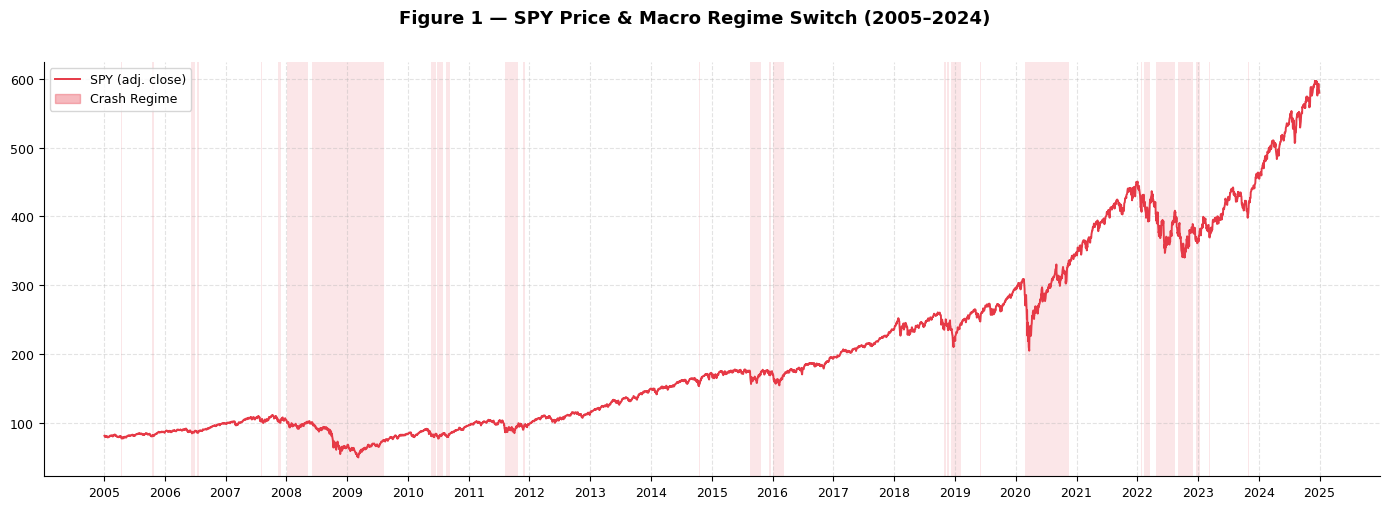

In [18]:
fig1 = plot_regime_overlay(prices_df=prices, regime_df=regime, start=OOS_START, end=OOS_END)
plt.show()

  Saved: plots/figure_2_capital_allocation.png


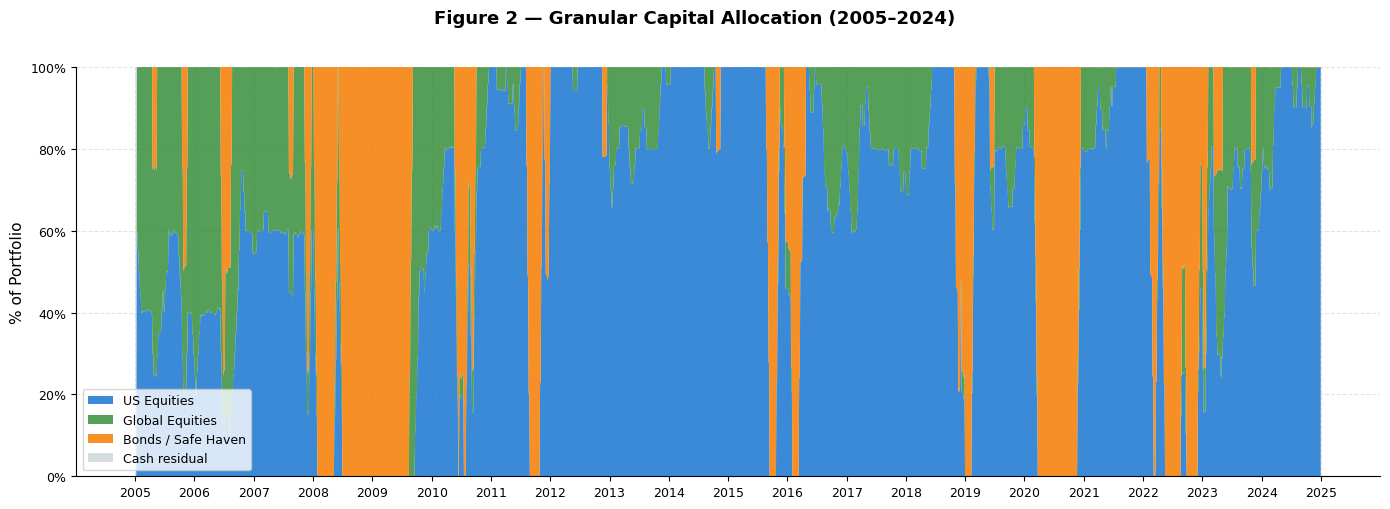

In [19]:
fig2 = plot_capital_allocation(daily_df=daily, regime_df=regime)
plt.show()

  Saved: plots/figure_3_equity_drawdown.png


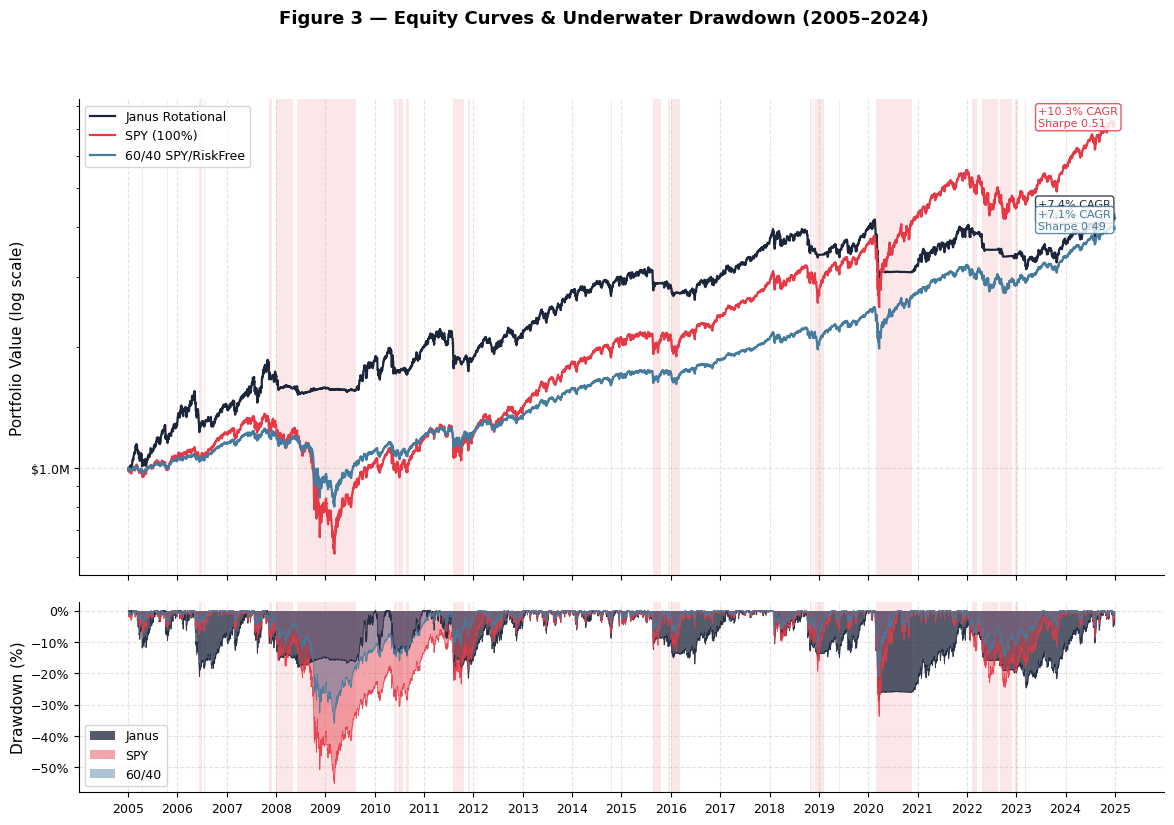

In [20]:
fig3 = plot_equity_and_drawdown(
    janus_curve=janus_curve, spy_curve=spy_curve, bench_curve=bench_6040,
    regime_df=regime, metrics_dict=metrics_dict,
)
plt.show()

  Saved: plots/figure_4_whites_reality_check.png


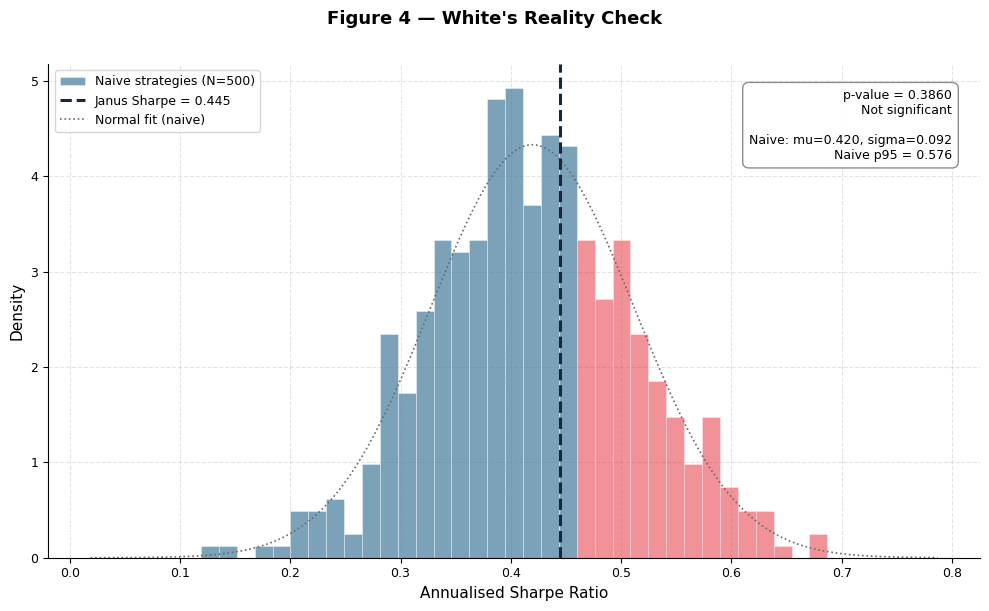

In [21]:
fig4 = plot_whites_test(whites_result=whites)
plt.show()

## 10. Regime-Partitioned Case Studies

Re-runs the Janus ladder independently for three distinct historical macro regimes, each starting with fresh $1M capital. This isolates how the strategy performs in fundamentally different market environments rather than averaging across them.

**Why partition?** A 20-year CAGR masks enormous variation across regimes. A strategy with a flat equity curve during the GFC but strong compounding afterward will *look* mediocre on aggregate metrics — and vice versa. Regime partitioning reveals whether the crash filter genuinely protects capital or merely delays losses.

**Regime definitions:**

| Sub-period | Label | Macro Character | Figures | Output dir |
|---|---|---|---|---|
| 2005–2010 | GFC & Recovery | Credit boom → financial crisis → stimulus recovery | 5–8 | `plots/regime_1_GFC/` |
| 2011–2019 | The Long Bull | Low-vol post-QE equity expansion, two minor corrections | 9–12 | `plots/regime_2_Bull/` |
| 2020–2024 | Modern Volatility | COVID shock, V-shaped recovery, inflation cycle, rate hikes | 13–16 | `plots/regime_3_Modern/` |

Each case study produces 4 figures (regime overlay, capital allocation, equity+drawdown, White's RC) saved to its own subdirectory. A White's Reality Check with 300 simulations is run independently for each sub-period.

In [22]:
def run_regime_subperiod(start, end, label, out_subdir):
    print(f'Running: {label} ({start} to {end})...')

    sub_regime = regime.loc[start:end]
    sub_sel    = selections.loc[start:end]

    sub_engine = LadderEngine(
        initial_capital=INITIAL_CAPITAL, execution_lag=1, n_tranches=4,
        slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION,
        asset_classes={
            'us_equity':     US_ETFS,
            'global_equity': GLOBAL_ETFS,
            'defensive':     DEFENSIVE_UNIVERSE,
        },
    )
    sub_result = sub_engine.run(prices_df=prices, sel_df=sub_sel, start=start, end=end)
    sub_daily  = sub_result.daily
    sub_janus  = sub_daily['portfolio_value'].rename('Janus Rotational')

    sub_spy  = build_spy_benchmark(prices, INITIAL_CAPITAL, start, end)
    sub_6040 = build_6040_benchmark(INITIAL_CAPITAL, start, end)
    common   = sub_janus.index
    sub_spy  = sub_spy.reindex(common, method='ffill')
    sub_6040 = sub_6040.reindex(common, method='ffill')

    m_j = compute_metrics(sub_janus)
    m_s = compute_metrics(sub_spy)
    m_b = compute_metrics(sub_6040)
    sub_metrics = {'janus': m_j, 'spy': m_s, '6040': m_b}

    sub_fridays = [
        d for d in selections.index
        if pd.Timestamp(start) <= d <= pd.Timestamp(end)
        and pd.notna(selections.loc[d, 'rank_1'])
    ]
    sub_whites = run_whites_reality_check(
        sub_janus, prices, sub_fridays, n_sims=300, seed=RANDOM_SEED
    )

    out_dir = PLOT_DIR / out_subdir
    out_dir.mkdir(exist_ok=True, parents=True)

    print(f'  {"Metric":<22} {"Janus":>12} {"SPY":>12} {"60/40":>10}')
    print(f'  {"-"*58}')
    for met_lbl, key, fmt in [
        ('CAGR',         'cagr',        '{:+.2%}'),
        ('Sharpe',       'sharpe',       '{:.4f}'),
        ('Max Drawdown', 'max_drawdown', '{:.2%}'),
        ('Calmar',       'calmar',       '{:.4f}'),
    ]:
        jv = fmt.format(m_j[key])
        sv = fmt.format(m_s[key])
        bv = fmt.format(m_b[key])
        print(f'  {met_lbl:<22} {jv:>12} {sv:>12} {bv:>10}')
    pval = sub_whites['p_value']
    print(f'  {"Whites RC p-value":<22} {pval:>12.4f}')

    return sub_daily, sub_janus, sub_spy, sub_6040, sub_regime, sub_metrics, sub_whites, out_dir


print('Regime subperiod helper defined.')

Regime subperiod helper defined.


Running: GFC and Recovery (2005-2010) (2005-01-01 to 2010-12-31)...
  Metric                        Janus          SPY      60/40
  ----------------------------------------------------------
  CAGR                        +12.25%       +2.78%     +3.09%
  Sharpe                       0.6736       0.1475     0.1446
  Max Drawdown                -21.04%      -55.19%    -35.97%
  Calmar                       0.5823       0.0504     0.0860
  Whites RC p-value            0.0300


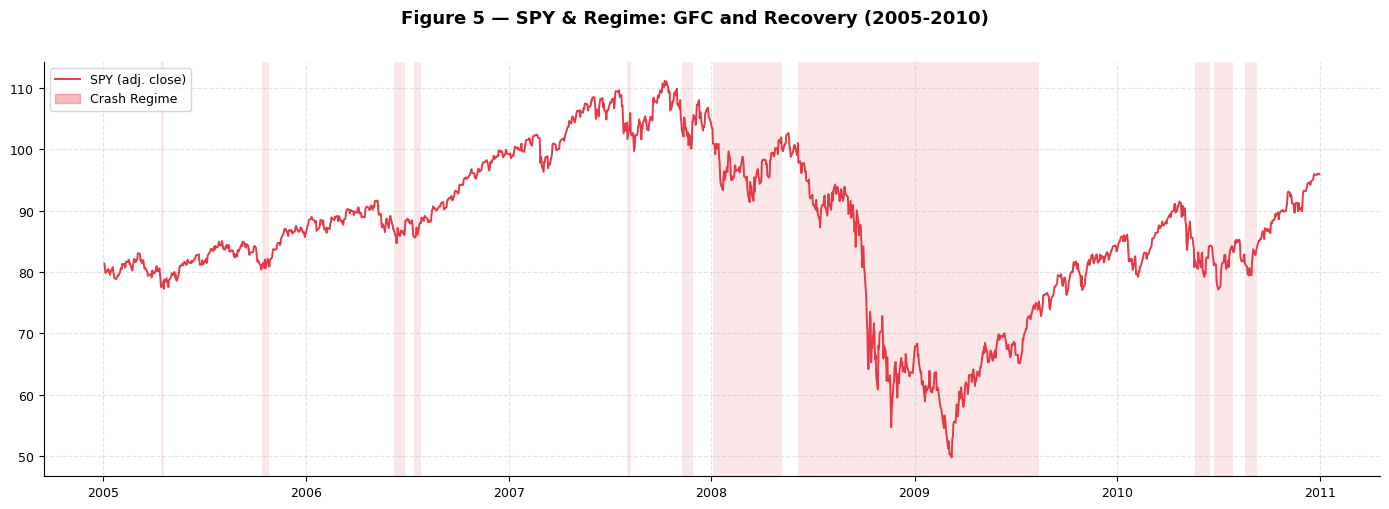

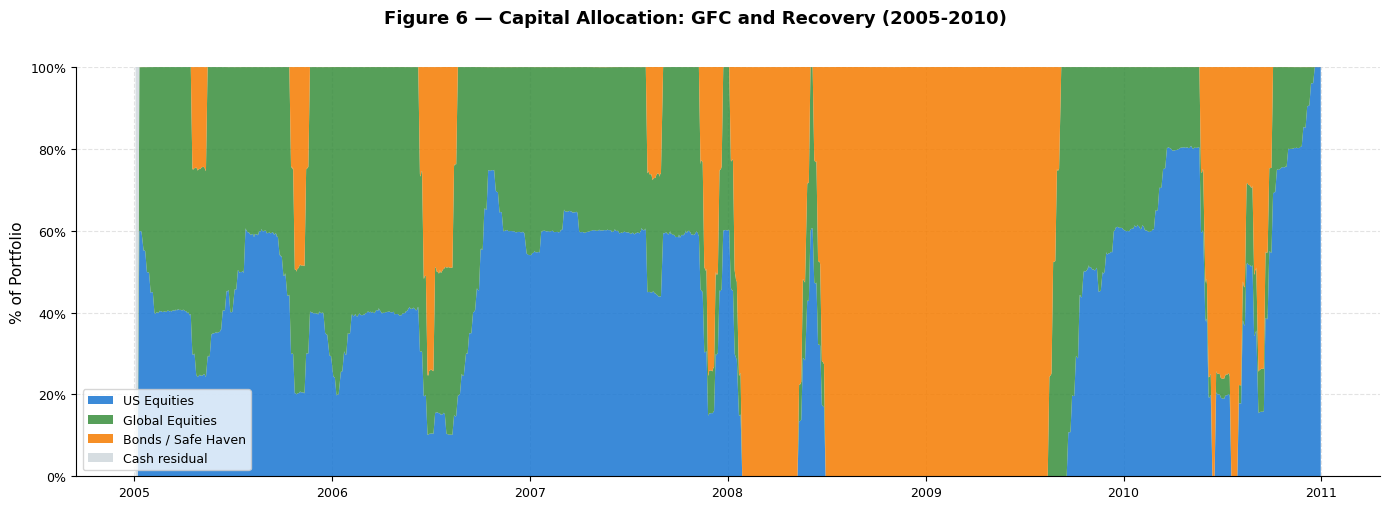

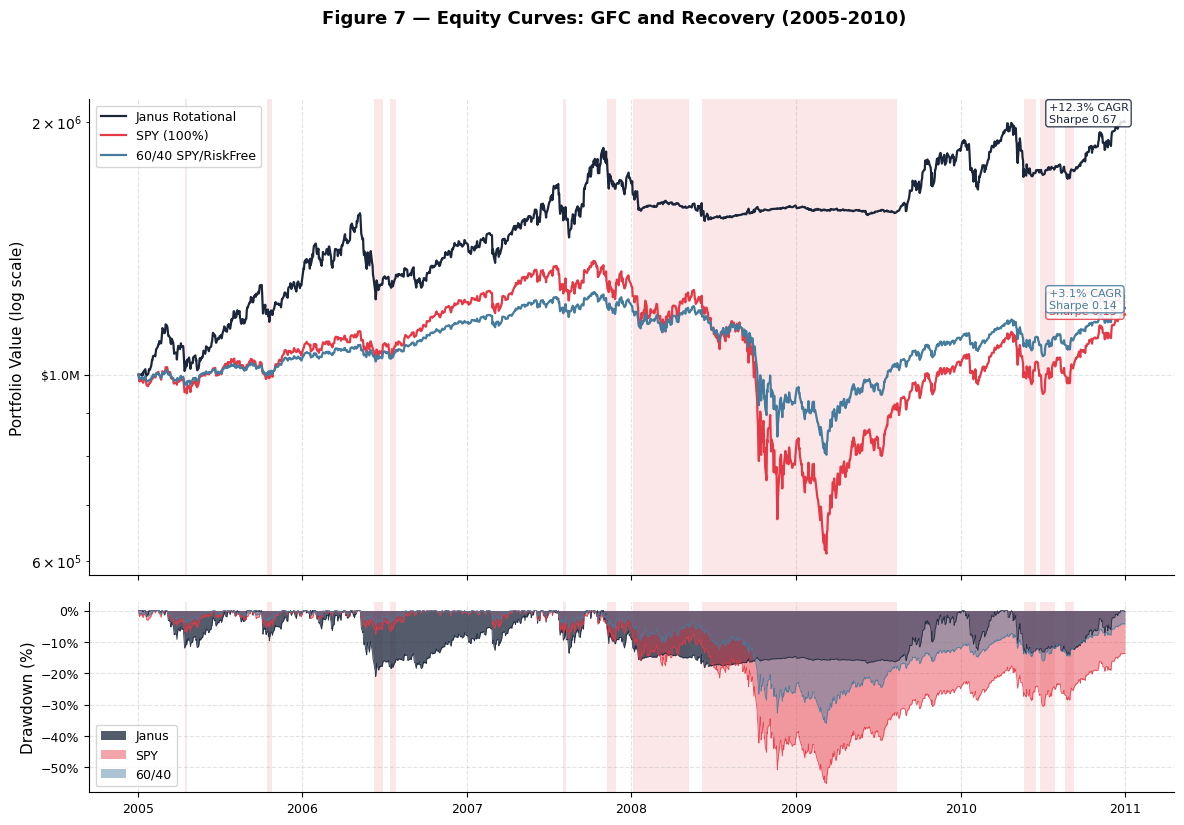

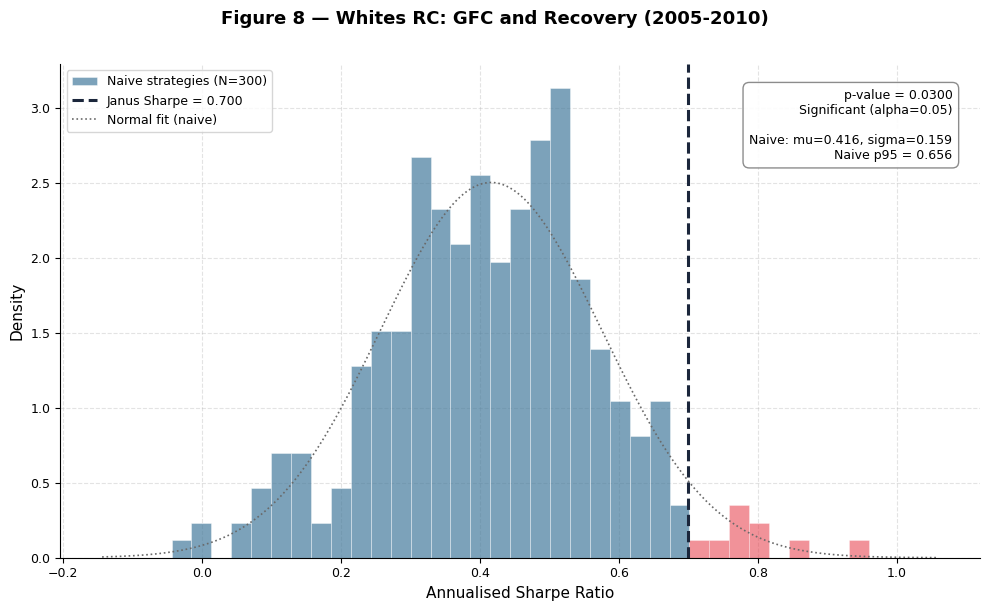

In [23]:
# === Case Study 1: GFC & Recovery (2005-2010) — Figures 5–8 ===
GFC_LABEL = 'GFC and Recovery (2005-2010)'
gfc_daily, gfc_janus, gfc_spy, gfc_6040, gfc_regime, gfc_metrics, gfc_whites, gfc_dir = \
    run_regime_subperiod('2005-01-01', '2010-12-31', GFC_LABEL, 'regime_1_GFC')

fig5 = plot_regime_overlay(prices_df=prices, regime_df=gfc_regime,
                           start='2005-01-01', end='2010-12-31', save=False)
fig5.suptitle(f'Figure 5 — SPY & Regime: {GFC_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig5.savefig(gfc_dir / 'figure_5_regime_overlay.png', bbox_inches='tight', dpi=200)
plt.show()

fig6 = plot_capital_allocation(daily_df=gfc_daily, regime_df=gfc_regime, save=False)
fig6.suptitle(f'Figure 6 — Capital Allocation: {GFC_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig6.savefig(gfc_dir / 'figure_6_capital_allocation.png', bbox_inches='tight', dpi=200)
plt.show()

fig7 = plot_equity_and_drawdown(gfc_janus, gfc_spy, gfc_6040,
                                gfc_regime, gfc_metrics, save=False)
fig7.suptitle(f'Figure 7 — Equity Curves: {GFC_LABEL}', fontsize=13, fontweight='bold')
fig7.savefig(gfc_dir / 'figure_7_equity_drawdown.png', bbox_inches='tight', dpi=200)
plt.show()

fig8 = plot_whites_test(whites_result=gfc_whites, save=False)
fig8.suptitle(f'Figure 8 — Whites RC: {GFC_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig8.savefig(gfc_dir / 'figure_8_whites_reality_check.png', bbox_inches='tight', dpi=200)
plt.show()

Running: The Long Bull (2011-2019) (2011-01-01 to 2019-12-31)...
  Metric                        Janus          SPY      60/40
  ----------------------------------------------------------
  CAGR                         +7.77%      +13.16%     +8.15%
  Sharpe                       0.4729       0.7965     0.7231
  Max Drawdown                -21.26%      -19.35%    -11.80%
  Calmar                       0.3655       0.6800     0.6907
  Whites RC p-value            0.5133


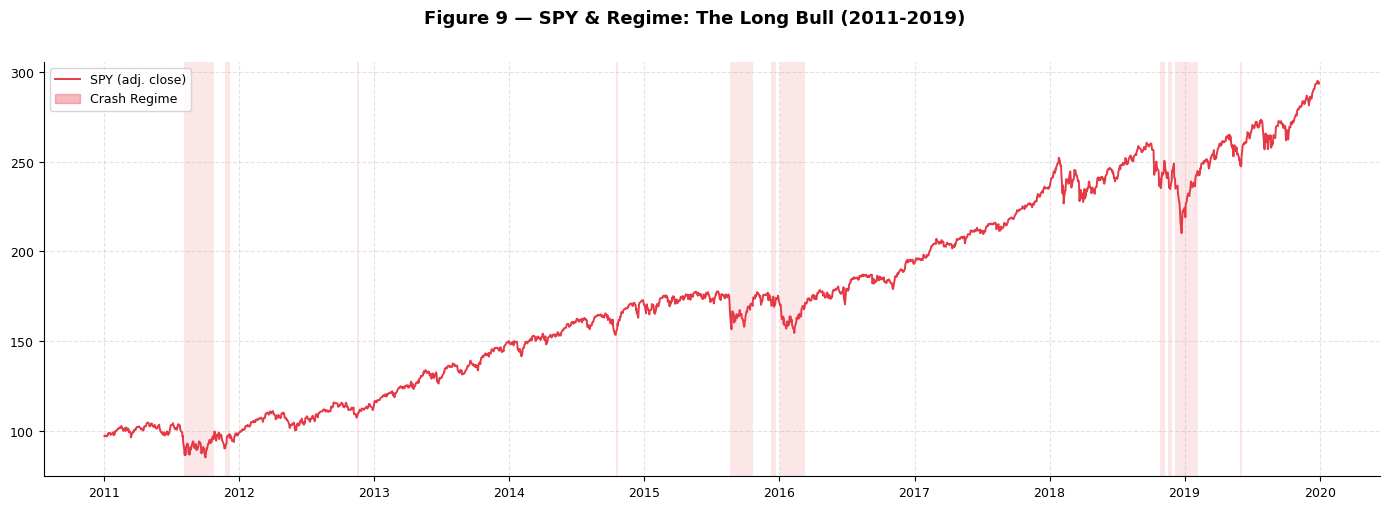

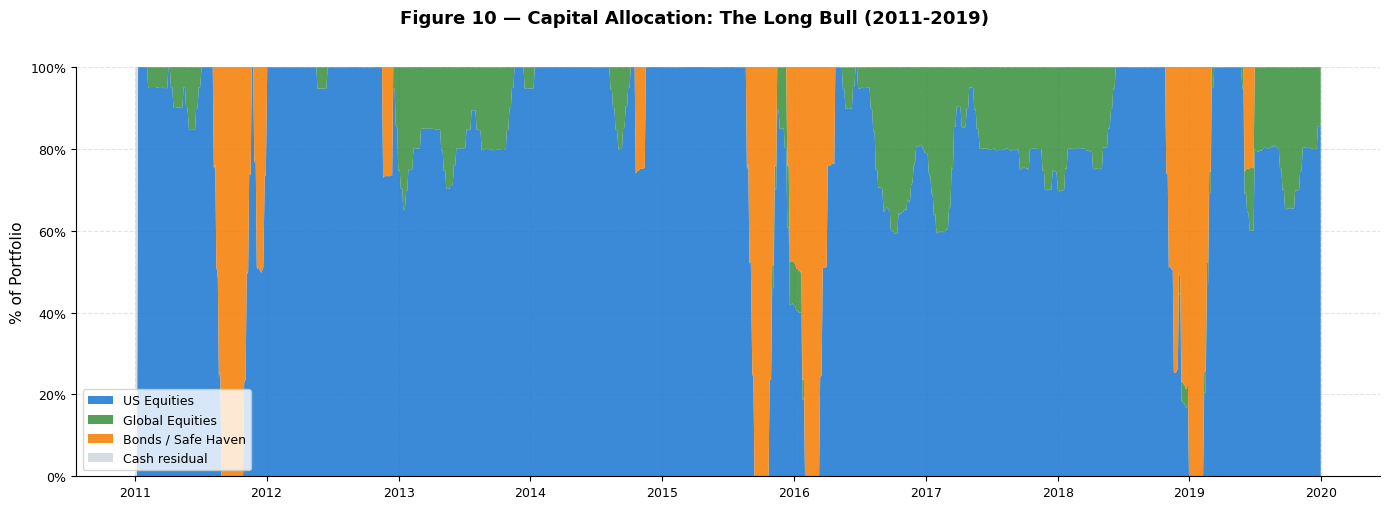

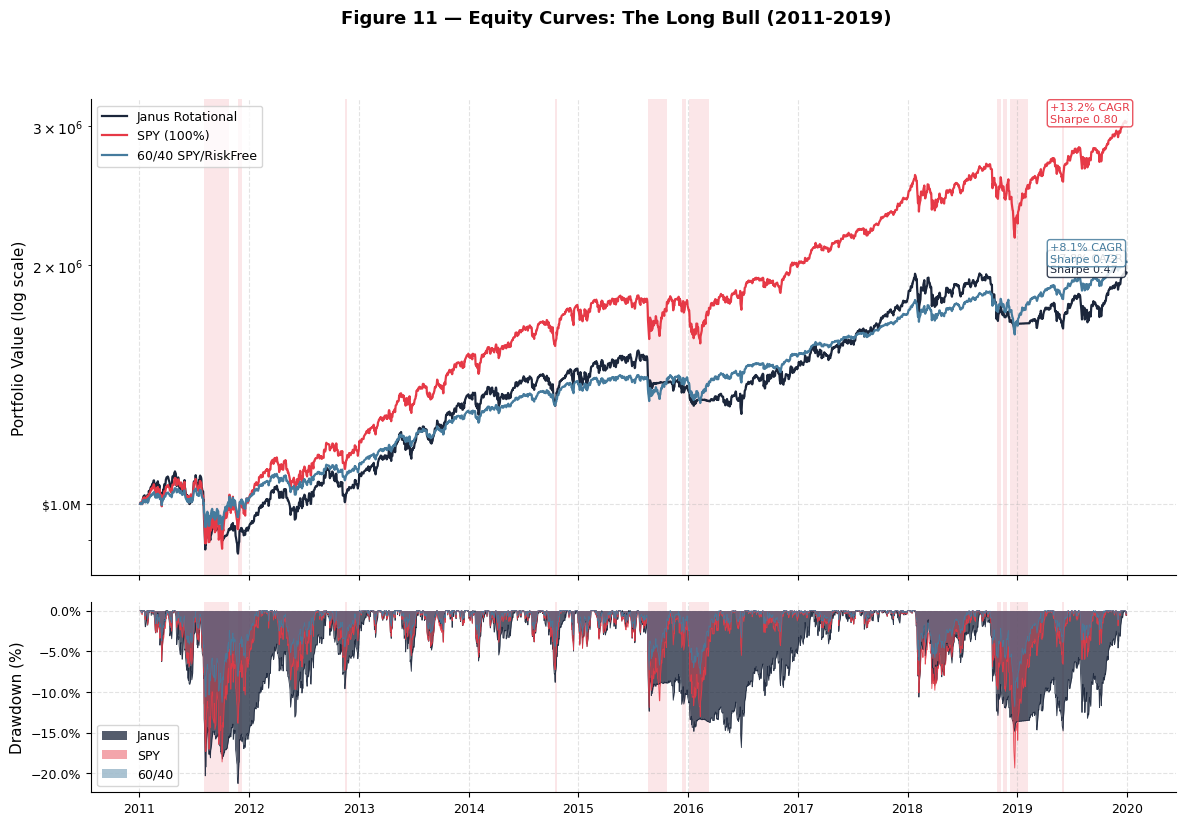

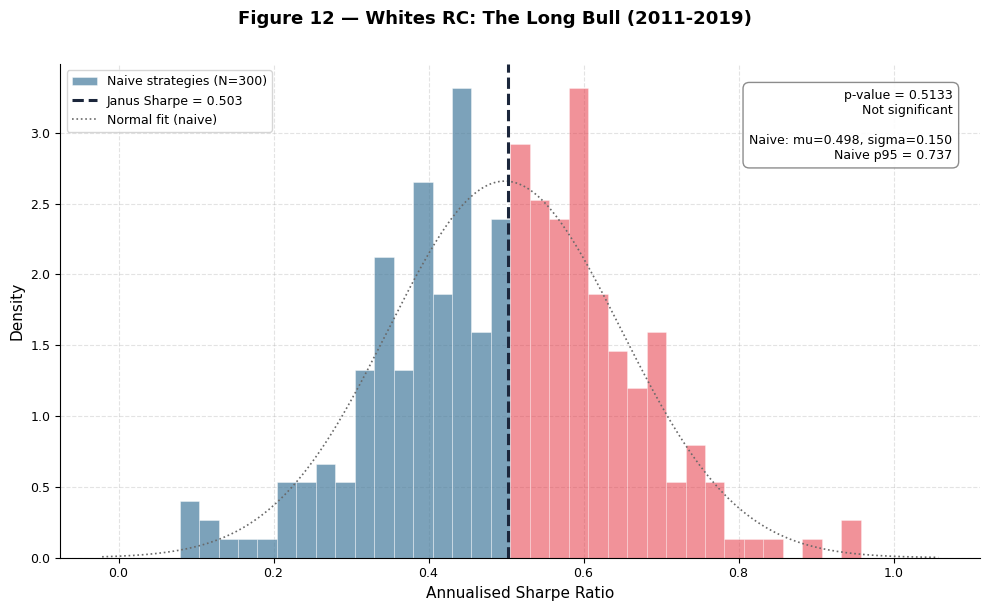

In [24]:
# === Case Study 2: The Long Bull (2011-2019) — Figures 9–12 ===
BULL_LABEL = 'The Long Bull (2011-2019)'
bull_daily, bull_janus, bull_spy, bull_6040, bull_regime, bull_metrics, bull_whites, bull_dir = \
    run_regime_subperiod('2011-01-01', '2019-12-31', BULL_LABEL, 'regime_2_Bull')

fig9 = plot_regime_overlay(prices_df=prices, regime_df=bull_regime,
                           start='2011-01-01', end='2019-12-31', save=False)
fig9.suptitle(f'Figure 9 — SPY & Regime: {BULL_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig9.savefig(bull_dir / 'figure_9_regime_overlay.png', bbox_inches='tight', dpi=200)
plt.show()

fig10 = plot_capital_allocation(daily_df=bull_daily, regime_df=bull_regime, save=False)
fig10.suptitle(f'Figure 10 — Capital Allocation: {BULL_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig10.savefig(bull_dir / 'figure_10_capital_allocation.png', bbox_inches='tight', dpi=200)
plt.show()

fig11 = plot_equity_and_drawdown(bull_janus, bull_spy, bull_6040,
                                 bull_regime, bull_metrics, save=False)
fig11.suptitle(f'Figure 11 — Equity Curves: {BULL_LABEL}', fontsize=13, fontweight='bold')
fig11.savefig(bull_dir / 'figure_11_equity_drawdown.png', bbox_inches='tight', dpi=200)
plt.show()

fig12 = plot_whites_test(whites_result=bull_whites, save=False)
fig12.suptitle(f'Figure 12 — Whites RC: {BULL_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig12.savefig(bull_dir / 'figure_12_whites_reality_check.png', bbox_inches='tight', dpi=200)
plt.show()

Running: Modern Volatility (2020-2024) (2020-01-01 to 2024-12-31)...
  Metric                        Janus          SPY      60/40
  ----------------------------------------------------------
  CAGR                         +1.39%      +14.37%     +9.98%
  Sharpe                       0.0278       0.6498     0.6598
  Max Drawdown                -28.10%      -33.72%    -21.22%
  Calmar                       0.0495       0.4263     0.4706
  Whites RC p-value            0.9600


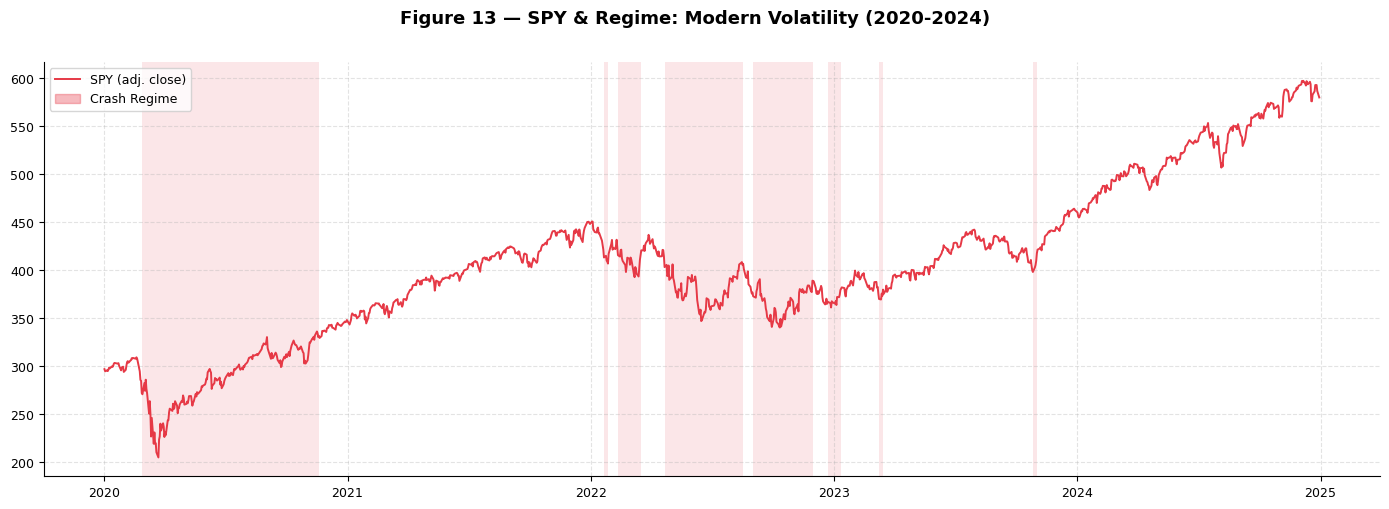

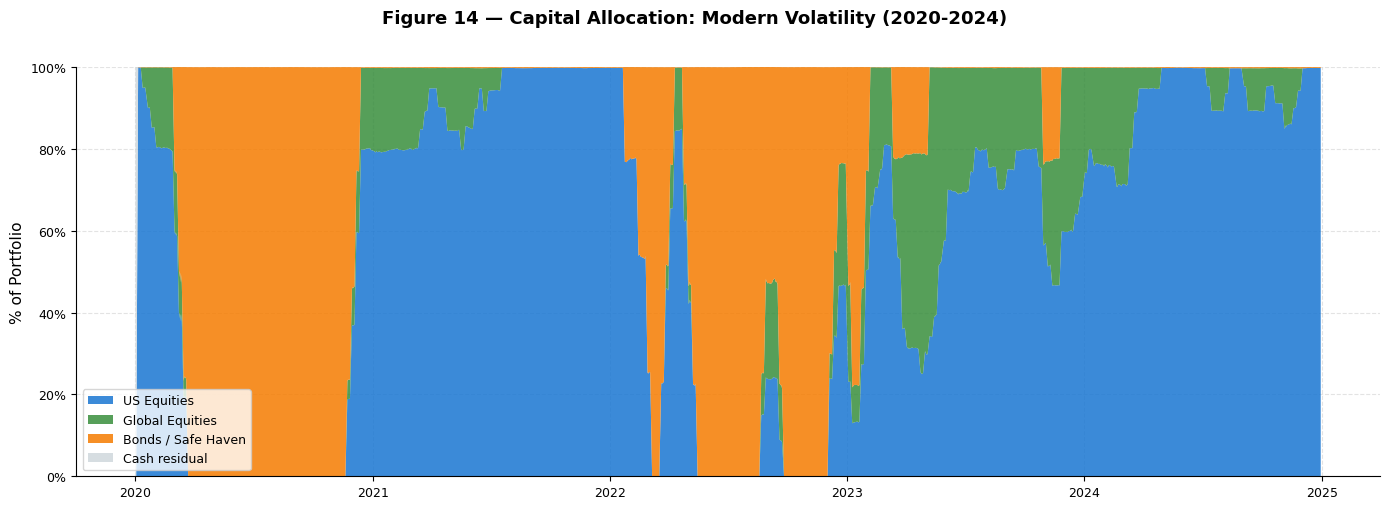

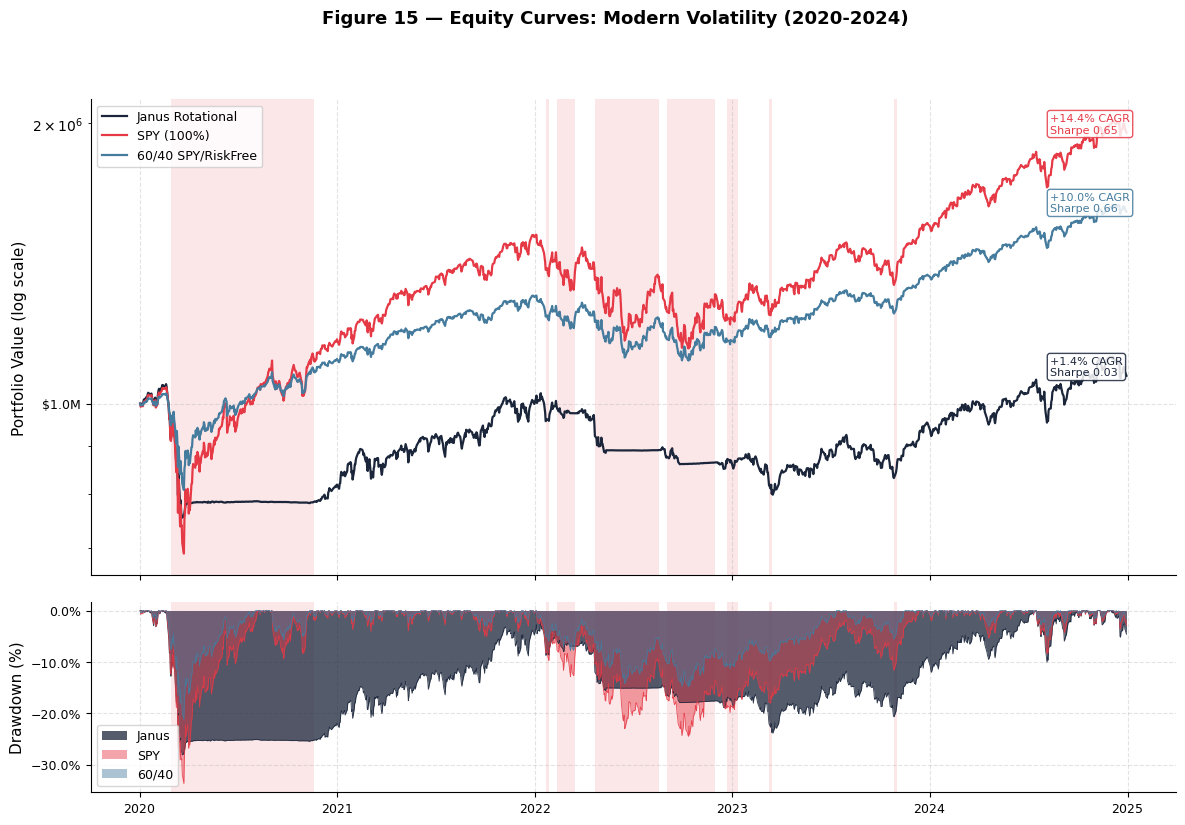

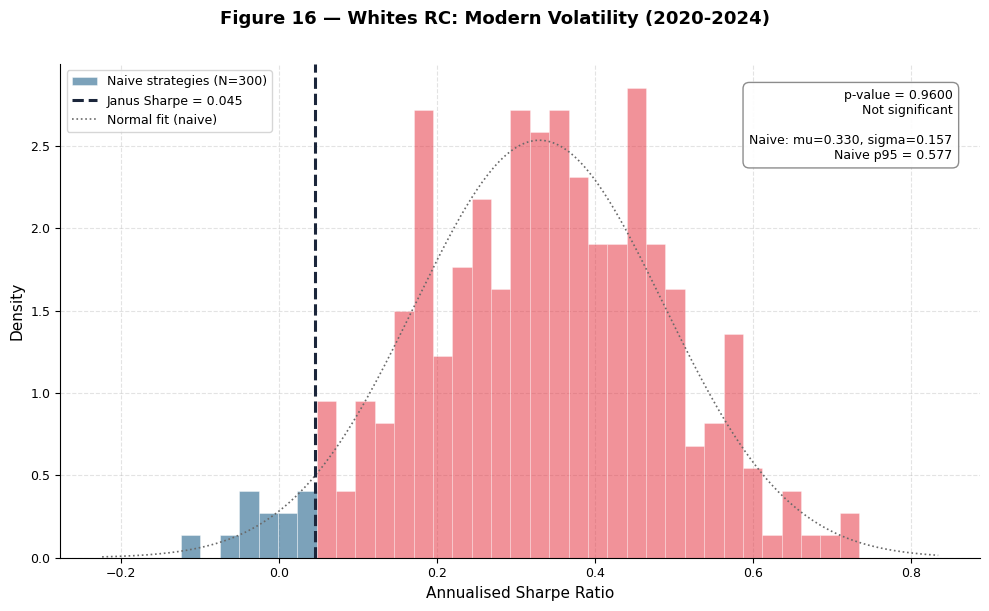

In [25]:
# === Case Study 3: Modern Volatility (2020-2024) — Figures 13–16 ===
MOD_LABEL = 'Modern Volatility (2020-2024)'
mod_daily, mod_janus, mod_spy, mod_6040, mod_regime, mod_metrics, mod_whites, mod_dir = \
    run_regime_subperiod('2020-01-01', '2024-12-31', MOD_LABEL, 'regime_3_Modern')

fig13 = plot_regime_overlay(prices_df=prices, regime_df=mod_regime,
                            start='2020-01-01', end='2024-12-31', save=False)
fig13.suptitle(f'Figure 13 — SPY & Regime: {MOD_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig13.savefig(mod_dir / 'figure_13_regime_overlay.png', bbox_inches='tight', dpi=200)
plt.show()

fig14 = plot_capital_allocation(daily_df=mod_daily, regime_df=mod_regime, save=False)
fig14.suptitle(f'Figure 14 — Capital Allocation: {MOD_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig14.savefig(mod_dir / 'figure_14_capital_allocation.png', bbox_inches='tight', dpi=200)
plt.show()

fig15 = plot_equity_and_drawdown(mod_janus, mod_spy, mod_6040,
                                 mod_regime, mod_metrics, save=False)
fig15.suptitle(f'Figure 15 — Equity Curves: {MOD_LABEL}', fontsize=13, fontweight='bold')
fig15.savefig(mod_dir / 'figure_15_equity_drawdown.png', bbox_inches='tight', dpi=200)
plt.show()

fig16 = plot_whites_test(whites_result=mod_whites, save=False)
fig16.suptitle(f'Figure 16 — Whites RC: {MOD_LABEL}', fontsize=13, fontweight='bold', y=1.01)
fig16.savefig(mod_dir / 'figure_16_whites_reality_check.png', bbox_inches='tight', dpi=200)
plt.show()

## 11. Robustness & Sensitivity Experiments

Five one-at-a-time parameter sweeps test where the strategy's performance breaks down ("Multiverse Audit"). Each experiment holds all other parameters fixed at their baseline values and varies only the target parameter across a meaningful range.

**Purpose:** Confirm that the strategy's returns are not a fragile artefact of one specific parameter choice. A robust strategy should degrade *gradually* as parameters move away from baseline, not collapse at the first perturbation.

| # | Experiment | Parameter swept | Baseline | Output |
|---|---|---|---|---|
| 1 | **Cost Sensitivity** | Slippage: 0, 1, 2★, 5, 10, 20, 50 bps | 2 bps | Fig 17 |
| 2 | **Momentum Windows** | (short, long): (21,63), (63,126)★, (63,252), (126,252) | (63,126) | Fig 18 |
| 3 | **Tranche Smoothing** | n_tranches: 1, 2, 4★, 6, 8, 12 | 4 | Fig 19 |
| 4 | **Reporting Lag** | Fundamental lag: 0, 15, 30, 45★, 90, 180 days | 45 days | Fig 20 |
| 5 | **Universe Breadth** | Narrow (11), Medium (18), Broad (20)★ tickers | Broad | Fig 21 |

★ = baseline configuration (highlighted in orange in bar charts). All outputs save to `plots/research/`.

> **Interpretation guide:** Look for monotonic degradation (good sign) vs. cliff edges (fragility). Pay particular attention to cost sensitivity — if alpha evaporates at 5 bps, the strategy is not viable in live trading.

In [26]:
# ── Experiment helpers ────────────────────────────────────────────────────────
RESEARCH_DIR = PLOT_DIR / 'research'
RESEARCH_DIR.mkdir(exist_ok=True, parents=True)


def run_backtest_curve(sel_df, slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION,
                       n_tranches=4, start=OOS_START, end=OOS_END):
    '''Run full backtest and return daily portfolio_value Series.'''
    eng = LadderEngine(
        initial_capital=INITIAL_CAPITAL, execution_lag=1,
        n_tranches=n_tranches, slippage=slippage, commission=commission,
    )
    result = eng.run(prices_df=prices, sel_df=sel_df, start=start, end=end)
    return result.daily['portfolio_value']


def run_fast_backtest(sel_df, slippage=DEFAULT_SLIPPAGE, commission=DEFAULT_COMMISSION,
                      n_tranches=4, start=OOS_START, end=OOS_END):
    '''Run full backtest and return metrics dict.'''
    return compute_metrics(
        run_backtest_curve(sel_df, slippage, commission, n_tranches, start, end)
    )


def _dollar_fmt(x, _):
    '''Y-axis formatter for dollar equity curves.'''
    if x >= 1e6:
        return f'${x/1e6:.1f}M'
    return f'${x/1e3:.0f}K'


def _setup_equity_ax(ax, title):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Portfolio Value ($M)', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(_dollar_fmt))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, loc='upper left')


print('Research helpers ready.')

Research helpers ready.


Experiment 1: Cost Sensitivity...


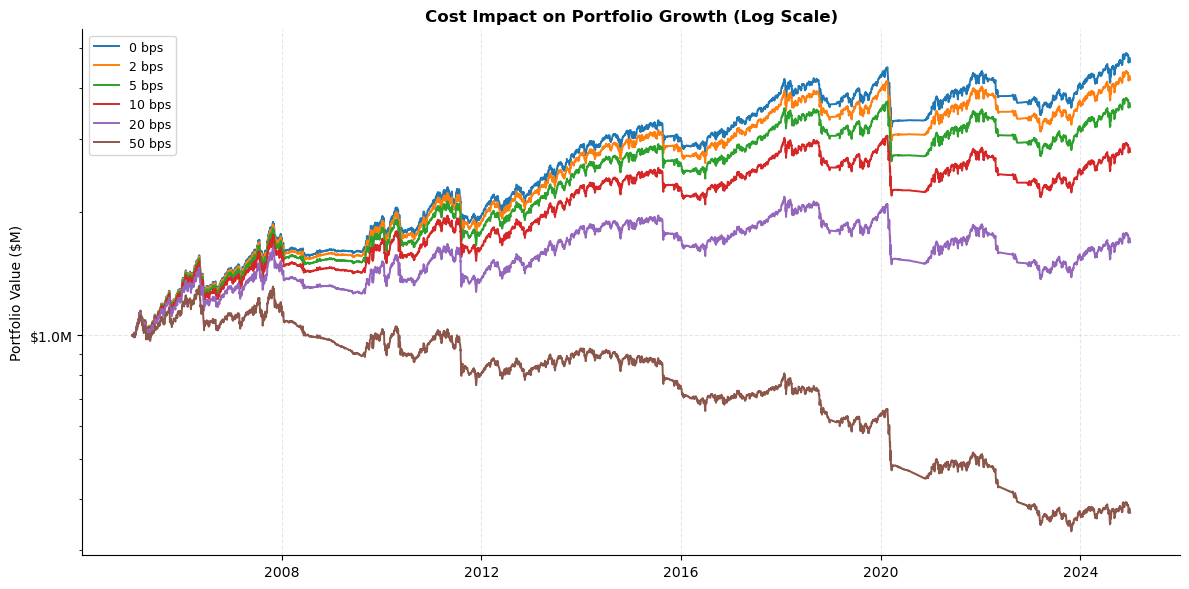

 slippage_bps      cagr  sharpe  max_drawdown
            0  0.079893  0.4633     -0.284308
            2  0.074435  0.4285     -0.284605
            5  0.066308  0.3764     -0.285019
           10  0.052885  0.2895     -0.291819
           20  0.026549  0.1158     -0.370464
           50 -0.048585 -0.4029     -0.747500
Saved -> research_1_cost_sensitivity.png


In [27]:
# === Experiment 1: Cost Impact on Portfolio Growth (Log Scale) ===
print('Experiment 1: Cost Sensitivity...')
slippage_bps = [0, 2, 5, 10, 20, 50]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, ax = plt.subplots(figsize=(12, 6))
rows = []
for bps, color in zip(slippage_bps, colors):
    curve = run_backtest_curve(selections, slippage=bps / 10_000)
    ax.semilogy(curve.index, curve, color=color, linewidth=1.4, label=f'{bps} bps')
    m = compute_metrics(curve)
    rows.append({'slippage_bps': bps, 'cagr': m['cagr'], 'sharpe': m['sharpe'],
                 'max_drawdown': m['max_drawdown']})

_setup_equity_ax(ax, 'Cost Impact on Portfolio Growth (Log Scale)')
fig.tight_layout()
fig.savefig(RESEARCH_DIR / 'research_1_cost_sensitivity.png', bbox_inches='tight', dpi=200)
plt.show()
print(pd.DataFrame(rows).to_string(index=False))
print(f'Saved -> research_1_cost_sensitivity.png')

Experiment 2: Momentum Windows...


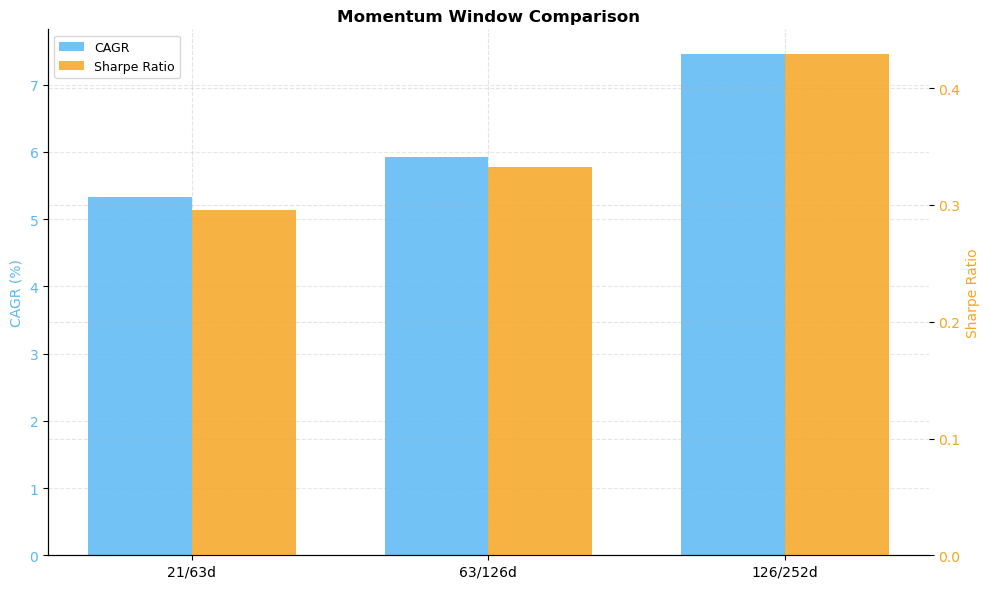

Saved -> research_2_momentum_windows.png


In [28]:
# === Experiment 2: Momentum Window Comparison (Dual-Axis Bar) ===
print('Experiment 2: Momentum Windows...')
window_configs = [
    ('21/63d',   21,  63),
    ('63/126d',  63, 126),
    ('126/252d', 126, 252),  # baseline,
]
labels, cagrs, sharpes = [], [], []
for label, short_w, long_w in window_configs:
    alt_sels = build_weekly_selections(
        prices_df=prices, volume_df=volume, regime_df=regime,
        equity_universe=EQUITY_UNIVERSE, bond_universe=DEFENSIVE_UNIVERSE,
        momentum_short=short_w, momentum_long=long_w,
    )
    m = run_fast_backtest(alt_sels)
    labels.append(label)
    cagrs.append(m['cagr'] * 100)
    sharpes.append(m['sharpe'])

x = np.arange(len(labels))
width = 0.35
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.bar(x - width / 2, cagrs,   width, color='#5bb8f5', alpha=0.85, label='CAGR')
ax2.bar(x + width / 2, sharpes, width, color='#f5a623', alpha=0.85, label='Sharpe Ratio')
ax1.set_title('Momentum Window Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('CAGR (%)',      color='#5bb8f5', fontsize=10)
ax2.set_ylabel('Sharpe Ratio',  color='#f5a623', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#5bb8f5')
ax2.tick_params(axis='y', labelcolor='#f5a623')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(RESEARCH_DIR / 'research_2_momentum_windows.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'Saved -> research_2_momentum_windows.png')

Experiment 3: Tranche Smoothing...


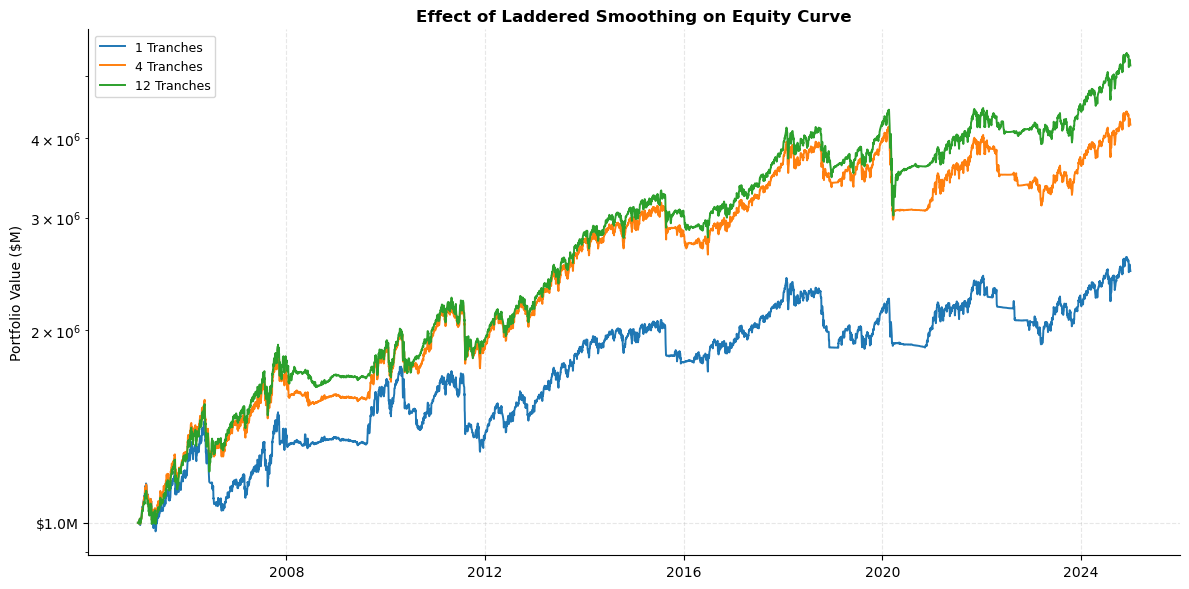

 n_tranches     cagr  sharpe  max_drawdown
          1 0.046440  0.2500     -0.276633
          4 0.074435  0.4285     -0.284605
         12 0.085974  0.4886     -0.316851
Saved -> research_3_tranche_smoothing.png


In [29]:
# === Experiment 3: Effect of Laddered Smoothing on Equity Curve ===
print('Experiment 3: Tranche Smoothing...')
tranche_show = [1, 4, 12]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(12, 6))
rows = []
for nt, color in zip(tranche_show, colors):
    curve = run_backtest_curve(selections, n_tranches=nt)
    ax.semilogy(curve.index, curve, color=color, linewidth=1.4, label=f'{nt} Tranches')
    m = compute_metrics(curve)
    rows.append({'n_tranches': nt, 'cagr': m['cagr'], 'sharpe': m['sharpe'],
                 'max_drawdown': m['max_drawdown']})

_setup_equity_ax(ax, 'Effect of Laddered Smoothing on Equity Curve')
fig.tight_layout()
fig.savefig(RESEARCH_DIR / 'research_3_tranche_smoothing.png', bbox_inches='tight', dpi=200)
plt.show()
print(pd.DataFrame(rows).to_string(index=False))
print(f'Saved -> research_3_tranche_smoothing.png')

Experiment 4: Reporting Lag...
  Lag   0d: CAGR +8.13%  Sharpe 0.469
  Lag  15d: CAGR +7.93%  Sharpe 0.457
  Lag  30d: CAGR +7.70%  Sharpe 0.444
  Lag  45d: CAGR +7.44%  Sharpe 0.428
  Lag  90d: CAGR +6.67%  Sharpe 0.380
  Lag 180d: CAGR +6.52%  Sharpe 0.374


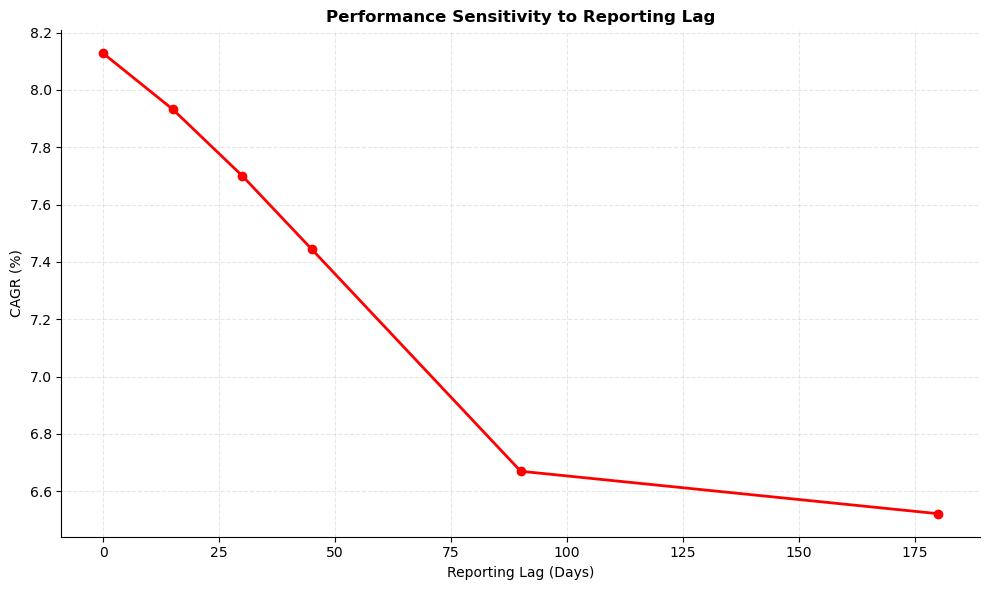

Saved -> research_4_fundamental_lag.png


In [30]:
# === Experiment 4: Performance Sensitivity to Reporting Lag ===
print('Experiment 4: Reporting Lag...')
lag_days_list = [0, 15, 30, 45, 90, 180]
lag_cagrs = []
for lag in lag_days_list:
    alt_fund = build_daily_fundamental_series(OOS_START, OOS_END, lag_days=lag)
    fridays_mask = alt_fund.index.weekday == 4
    alt_weekly = alt_fund.loc[fridays_mask].copy()
    alt_weekly['fundamental_crash'] = (
        (alt_weekly['altman_z_raw'] < ALTMAN_CRASH_THRESHOLD) |
        (alt_weekly['piotroski_f_raw'] < PIOTROSKI_CRASH_THRESHOLD)
    )
    alt_weekly['technical_crash'] = (
        regime['technical_crash'].reindex(alt_weekly.index, method='ffill').fillna(False)
    )
    alt_weekly['crash_regime'] = alt_weekly['fundamental_crash'] | alt_weekly['technical_crash']
    alt_sels = build_weekly_selections(
        prices_df=prices, volume_df=volume, regime_df=alt_weekly,
        equity_universe=EQUITY_UNIVERSE, bond_universe=DEFENSIVE_UNIVERSE,
        momentum_short=MOMENTUM_SHORT_WINDOW, momentum_long=MOMENTUM_LONG_WINDOW,
    )
    m = run_fast_backtest(alt_sels)
    lag_cagrs.append(m['cagr'] * 100)
    print(f'  Lag {lag:>3}d: CAGR {m["cagr"]:+.2%}  Sharpe {m["sharpe"]:.3f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lag_days_list, lag_cagrs, color='red', marker='o',
        linewidth=2, markersize=6, markerfacecolor='red')
ax.set_title('Performance Sensitivity to Reporting Lag', fontsize=12, fontweight='bold')
ax.set_xlabel('Reporting Lag (Days)', fontsize=10)
ax.set_ylabel('CAGR (%)', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
fig.tight_layout()
fig.savefig(RESEARCH_DIR / 'research_4_fundamental_lag.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'Saved -> research_4_fundamental_lag.png')

Experiment 5: Universe Breadth...
  Global Diversification: CAGR +7.44%  Sharpe 0.428
  US Tech Concentration: CAGR +6.52%  Sharpe 0.392


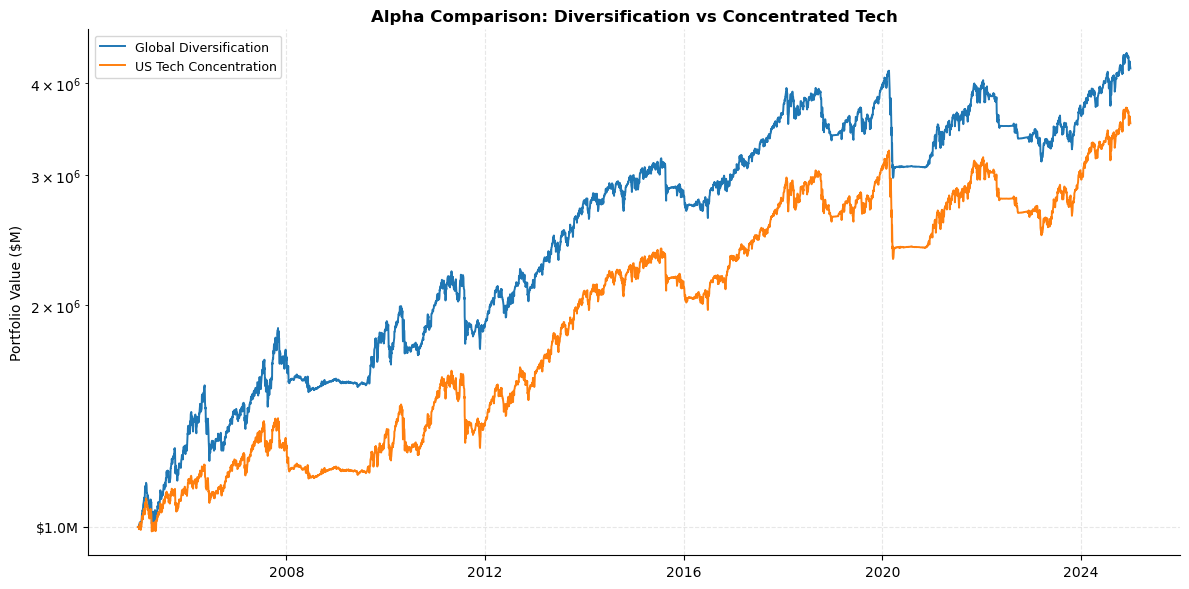

              universe     cagr  sharpe  max_drawdown
Global Diversification 0.074435  0.4285     -0.284605
 US Tech Concentration 0.065237  0.3915     -0.287634
Saved -> research_5_universe_comparison.png
All 5 sensitivity experiments complete.


In [31]:
# === Experiment 5: Alpha Comparison — Diversification vs Concentrated Tech ===
print('Experiment 5: Universe Breadth...')

# Global Diversification: full 20-ticker universe (US + international + sectors)
# US Tech Concentration: US-only large/mid cap ETFs — no international exposure
US_ONLY_UNIVERSE = ['SPY', 'QQQ', 'DIA', 'IWM', 'MDY',
                    'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLV']

configs = [
    ('Global Diversification', EQUITY_UNIVERSE,  '#1f77b4'),
    ('US Tech Concentration',  US_ONLY_UNIVERSE,  '#ff7f0e'),
]

fig, ax = plt.subplots(figsize=(12, 6))
rows = []
for label, eq_universe, color in configs:
    valid_eq   = [t for t in eq_universe    if t in prices.columns]
    valid_bond = [t for t in DEFENSIVE_UNIVERSE if t in prices.columns]
    sub_sels = build_weekly_selections(
        prices_df=prices, volume_df=volume, regime_df=regime,
        equity_universe=valid_eq, bond_universe=valid_bond,
        momentum_short=MOMENTUM_SHORT_WINDOW, momentum_long=MOMENTUM_LONG_WINDOW,
    )
    curve = run_backtest_curve(sub_sels)
    ax.semilogy(curve.index, curve, color=color, linewidth=1.4, label=label)
    m = compute_metrics(curve)
    rows.append({'universe': label, 'cagr': m['cagr'], 'sharpe': m['sharpe'],
                 'max_drawdown': m['max_drawdown']})
    print(f'  {label}: CAGR {m["cagr"]:+.2%}  Sharpe {m["sharpe"]:.3f}')

ax.set_title('Alpha Comparison: Diversification vs Concentrated Tech',
             fontsize=12, fontweight='bold')
_setup_equity_ax(ax, 'Alpha Comparison: Diversification vs Concentrated Tech')
fig.tight_layout()
fig.savefig(RESEARCH_DIR / 'research_5_universe_comparison.png', bbox_inches='tight', dpi=200)
plt.show()
print(pd.DataFrame(rows).to_string(index=False))
print(f'Saved -> research_5_universe_comparison.png')
print('All 5 sensitivity experiments complete.')